# Tema 3 - Análisis de la Respuesta Temporal

**Fundamentos de Control - GIERM**

---

## Objetivos de aprendizaje

- Identificar y generar las señales de prueba estándar (impulso, escalón, rampa, parábola)
- Calcular y graficar la respuesta temporal de sistemas de **primer orden** ante entrada escalón
- Calcular y graficar la respuesta temporal de sistemas de **segundo orden**, relacionando $\zeta$, $\omega_n$ con sobrepaso, tiempo de establecimiento y tiempo de subida
- Localizar polos en el plano $s$ e interpretar su efecto sobre la estabilidad y la forma de la respuesta
- Aplicar el **criterio de Routh-Hurwitz** para determinar estabilidad y rangos de parámetros
- Identificar modelos de primer y segundo orden a partir de curvas experimentales de respuesta al escalón

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'   # azul - curvas principales
COLOR_RECTA = '#cb181d'       # rojo - límites, referencias
COLOR_PUNTO = '#238b45'       # verde - puntos de operación, resultados
COLOR_TRANS = '#ff7f00'       # naranja - transitorio
COLOR_PERM = '#6a3d9a'        # púrpura - régimen permanente

print('Configuración lista.')

Configuración lista.


---

## 1. Señales de prueba estándar

En el análisis temporal de sistemas de control se utilizan **señales de prueba** normalizadas para estudiar el comportamiento del sistema. Las cuatro señales fundamentales son:

| Señal | Expresión temporal | Transformada de Laplace |
|-------|-------------------|------------------------|
| **Impulso** (delta de Dirac) | $\delta(t)$ | $1$ |
| **Escalón unitario** | $u(t) = 1,\; t \geq 0$ | $\dfrac{1}{s}$ |
| **Rampa unitaria** | $r(t) = t \cdot u(t)$ | $\dfrac{1}{s^2}$ |
| **Parábola unitaria** | $p(t) = \dfrac{t^2}{2} \cdot u(t)$ | $\dfrac{1}{s^3}$ |

El **escalón** es la señal de prueba más utilizada porque representa un cambio brusco en la referencia (la situación más exigente y frecuente en la práctica).

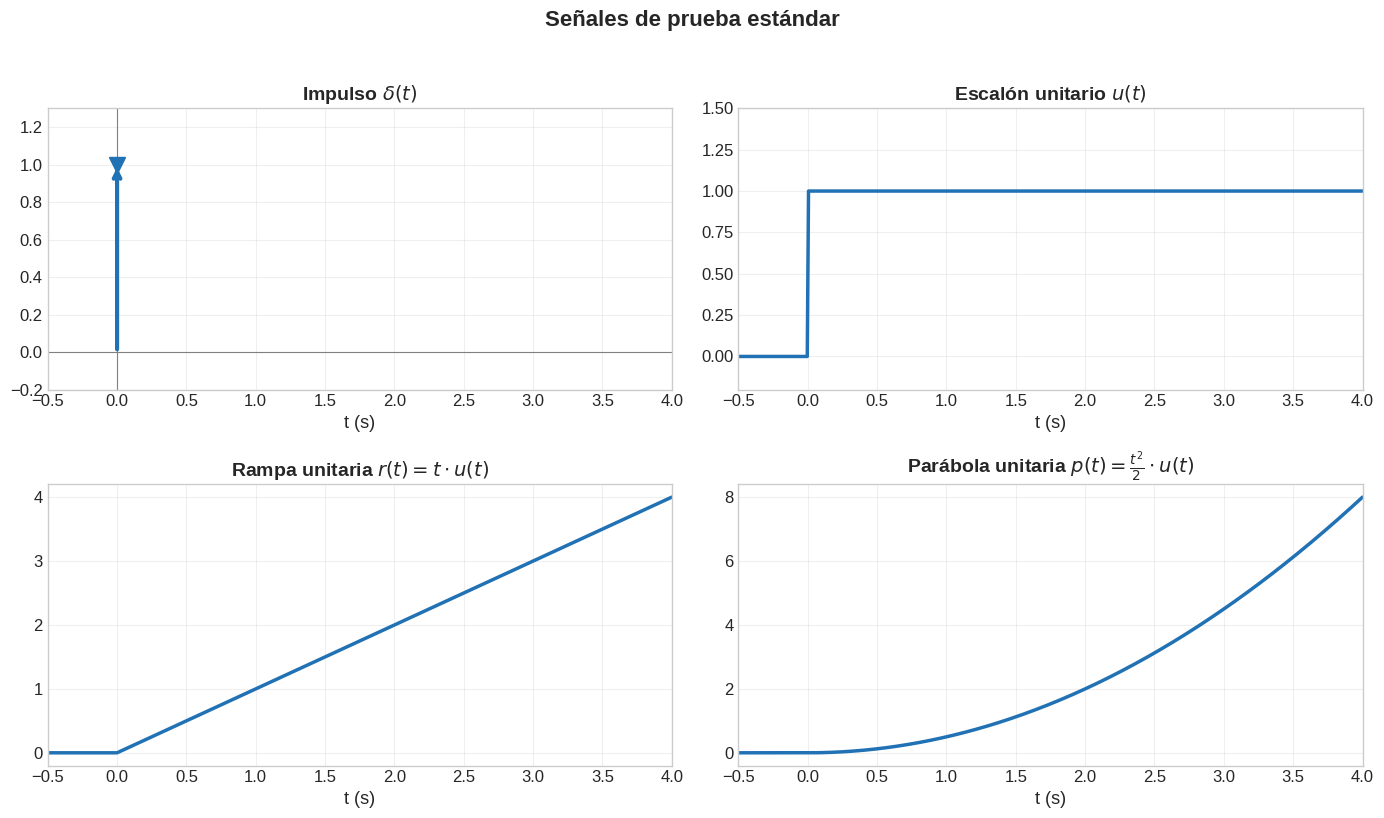

In [2]:
# PLOT 1: Señales de prueba estándar (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

t = np.linspace(-0.5, 4, 500)
t_pos = np.maximum(t, 0)

# Impulso
ax = axes[0, 0]
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
ax.annotate('', xy=(0, 1), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=3))
ax.plot(0, 1, 'v', color=COLOR_PRINCIPAL, ms=12)
ax.set_title(r'Impulso $\delta(t)$', fontweight='bold')
ax.set_xlabel('t (s)')
ax.set_ylim(-0.2, 1.3)
ax.grid(True, alpha=0.3)

# Escalón
ax = axes[0, 1]
escalon = np.where(t >= 0, 1, 0)
ax.plot(t, escalon, color=COLOR_PRINCIPAL, lw=2.5)
ax.set_title(r'Escalón unitario $u(t)$', fontweight='bold')
ax.set_xlabel('t (s)')
ax.set_ylim(-0.2, 1.5)
ax.grid(True, alpha=0.3)

# Rampa
ax = axes[1, 0]
rampa = np.where(t >= 0, t, 0)
ax.plot(t, rampa, color=COLOR_PRINCIPAL, lw=2.5)
ax.set_title(r'Rampa unitaria $r(t) = t \cdot u(t)$', fontweight='bold')
ax.set_xlabel('t (s)')
ax.grid(True, alpha=0.3)

# Parábola
ax = axes[1, 1]
parabola = np.where(t >= 0, t**2 / 2, 0)
ax.plot(t, parabola, color=COLOR_PRINCIPAL, lw=2.5)
ax.set_title(r'Parábola unitaria $p(t) = \frac{t^2}{2} \cdot u(t)$', fontweight='bold')
ax.set_xlabel('t (s)')
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlim(-0.5, 4)

plt.suptitle('Señales de prueba estándar', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 2. Descomposición de la respuesta temporal

La respuesta total de un sistema lineal ante una entrada se puede descomponer en dos partes:

$$\boxed{y(t) = y_{\text{transitorio}}(t) + y_{\text{permanente}}(t)}$$

- **Respuesta transitoria** $y_{\text{transitorio}}(t)$: debida a las condiciones iniciales y a la dinámica propia del sistema. Se extingue con el tiempo si el sistema es estable.
- **Respuesta en régimen permanente** $y_{\text{permanente}}(t)$: la parte que persiste cuando $t \to \infty$. Depende de la entrada aplicada.

**Truco para el examen:** La respuesta transitoria está asociada a los **polos del sistema** (raíces del denominador de $G(s)$), mientras que la respuesta permanente está asociada a los **polos de la entrada**.

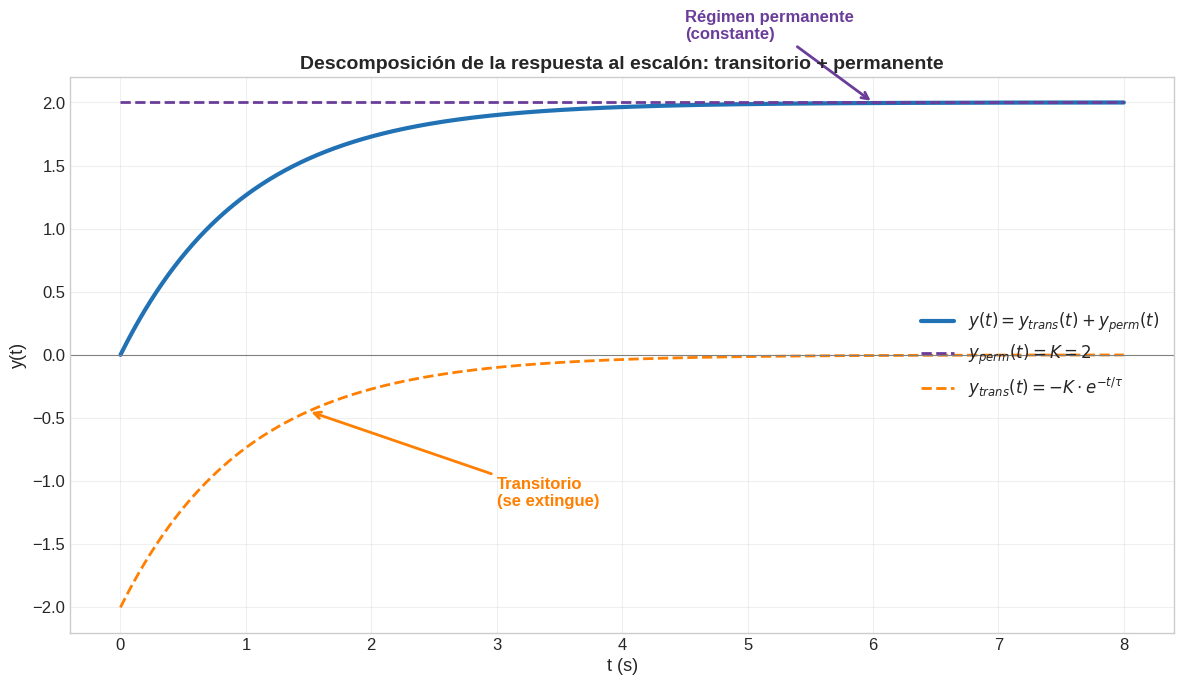

In [3]:
# PLOT 2: Descomposición transitorio + permanente
t = np.linspace(0, 8, 500)
K = 2.0
tau = 1.0

y_total = K * (1 - np.exp(-t / tau))
y_permanente = np.full_like(t, K)
y_transitorio = -K * np.exp(-t / tau)

fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(t, y_total, color=COLOR_PRINCIPAL, lw=3, label=r'$y(t) = y_{trans}(t) + y_{perm}(t)$')
ax.plot(t, y_permanente, '--', color=COLOR_PERM, lw=2, label=r'$y_{perm}(t) = K = 2$')
ax.plot(t, y_transitorio, '--', color=COLOR_TRANS, lw=2, label=r'$y_{trans}(t) = -K \cdot e^{-t/\tau}$')
ax.axhline(0, color='gray', lw=0.8)

ax.annotate('Transitorio\n(se extingue)', xy=(1.5, -K * np.exp(-1.5 / tau)),
            xytext=(3, -1.2), fontsize=12, color=COLOR_TRANS, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_TRANS, lw=2))

ax.annotate('Régimen permanente\n(constante)', xy=(6, K),
            xytext=(4.5, 2.5), fontsize=12, color=COLOR_PERM, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PERM, lw=2))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Descomposición de la respuesta al escalón: transitorio + permanente', fontweight='bold')
ax.legend(fontsize=12, loc='right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 3. Parámetros temporales de la respuesta al escalón

Los parámetros que caracterizan la calidad de la respuesta al escalón son:

| Parámetro | Símbolo | Descripción |
|-----------|---------|-------------|
| **Tiempo de subida** | $t_r$ | Tiempo en ir del 10% al 90% del valor final (o de 0 al 100% en 2º orden subamortiguado) |
| **Tiempo de pico** | $t_p$ | Tiempo en alcanzar el primer máximo |
| **Sobrepaso máximo** | $SO\%$ | Porcentaje que excede el valor final: $SO\% = \dfrac{y_{\max} - y(\infty)}{y(\infty)} \cdot 100$ |
| **Tiempo de establecimiento** | $t_s$ | Tiempo para entrar y permanecer en la banda $\pm 2\%$ (o $\pm 5\%$) del valor final |
| **Error en régimen permanente** | $e_{ss}$ | Diferencia entre referencia y salida cuando $t \to \infty$ |

Estos parámetros son **especificaciones de diseño**: el ingeniero de control los utiliza para evaluar si el sistema cumple los requisitos.

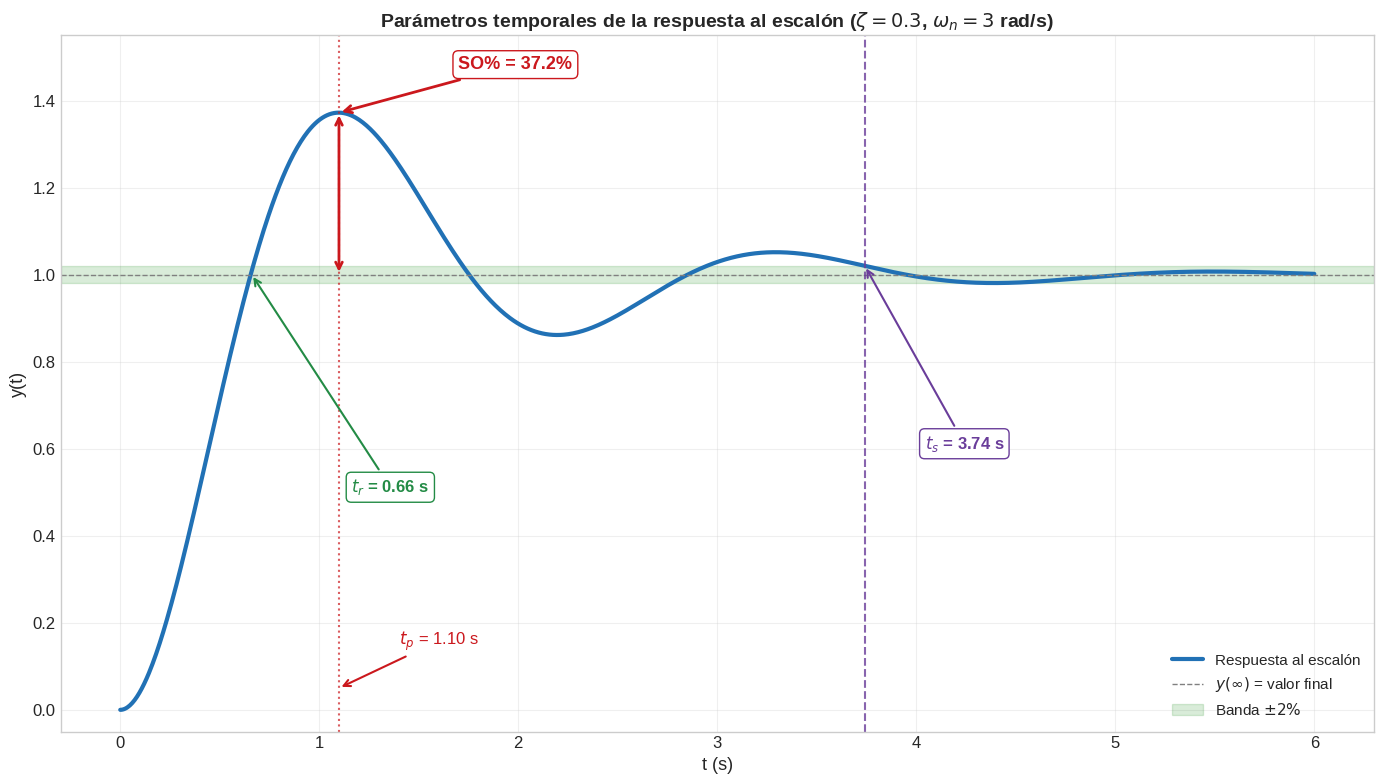

In [4]:
# PLOT 3: Respuesta al escalón con parámetros temporales anotados
wn = 3.0
zeta = 0.3
K = 1.0

sys_2 = signal.TransferFunction([K * wn**2], [1, 2 * zeta * wn, wn**2])
t, y = signal.step(sys_2, T=np.linspace(0, 6, 1000))

y_final = K
y_max = np.max(y)
t_peak = t[np.argmax(y)]
SO = (y_max - y_final) / y_final * 100

# Tiempo de subida (0% a 100% del valor final, primer cruce)
idx_rise = np.where(y >= y_final)[0][0]
t_rise = t[idx_rise]

# Tiempo de establecimiento (banda ±2%)
band = 0.02 * y_final
idx_settle = np.where(np.abs(y - y_final) > band)[0]
t_settle = t[idx_settle[-1]] if len(idx_settle) > 0 else t[-1]

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(t, y, color=COLOR_PRINCIPAL, lw=3, label='Respuesta al escalón')
ax.axhline(y_final, color='gray', ls='--', lw=1, label=r'$y(\infty)$ = valor final')

# Banda ±2%
ax.axhspan(y_final - band, y_final + band, alpha=0.15, color='green', label=r'Banda $\pm 2\%$')

# Sobrepaso
ax.annotate(f'SO% = {SO:.1f}%', xy=(t_peak, y_max),
            xytext=(t_peak + 0.6, y_max + 0.1), fontsize=13, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))

# Flecha vertical de sobrepaso
ax.annotate('', xy=(t_peak, y_final), xytext=(t_peak, y_max),
            arrowprops=dict(arrowstyle='<->', color=COLOR_RECTA, lw=2))

# Tiempo de pico
ax.axvline(t_peak, color=COLOR_RECTA, ls=':', lw=1.5, alpha=0.7)
ax.annotate(f'$t_p$ = {t_peak:.2f} s', xy=(t_peak, 0.05),
            xytext=(t_peak + 0.3, 0.15), fontsize=12, color=COLOR_RECTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=1.5))

# Tiempo de subida
ax.annotate(f'$t_r$ = {t_rise:.2f} s', xy=(t_rise, y_final),
            xytext=(t_rise + 0.5, 0.5), fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

# Tiempo de establecimiento
ax.axvline(t_settle, color=COLOR_PERM, ls='--', lw=1.5, alpha=0.8)
ax.annotate(f'$t_s$ = {t_settle:.2f} s', xy=(t_settle, y_final + band),
            xytext=(t_settle + 0.3, 0.6), fontsize=12, color=COLOR_PERM, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PERM, lw=1.5),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PERM))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Parámetros temporales de la respuesta al escalón ($\zeta=0.3$, $\omega_n=3$ rad/s)',
             fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(-0.05, 1.55)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación visual de los parámetros:**

- **$t_r$ (tiempo de subida):** Indica la **velocidad** de la respuesta. Menor $t_r$ = respuesta más rápida.
- **$SO\%$ (sobrepaso):** Indica la **oscilación**. Mayor SO% = más oscilaciones. En muchas aplicaciones se exige SO% < 10%.
- **$t_s$ (tiempo de establecimiento):** Indica cuándo se puede considerar que la respuesta ha llegado a su valor final.
- **$t_p$ (tiempo de pico):** Solo existe si hay sobrepaso (sistemas subamortiguados).

**Compromiso fundamental:** No se puede reducir $t_r$ y SO% simultáneamente. Menor $\zeta$ $\to$ menor $t_r$ pero mayor SO%.

---

## 4. Sistemas de primer orden

### 4.1 Función de transferencia

La forma estándar de un sistema de primer orden es:

$$\boxed{G(s) = \frac{K}{\tau s + 1}}$$

donde:
- $K$ = **ganancia estática** (valor final de la respuesta al escalón unitario)
- $\tau$ = **constante de tiempo** (en segundos)

### 4.2 Respuesta al escalón unitario

$$\boxed{y(t) = K\left(1 - e^{-t/\tau}\right), \quad t \geq 0}$$

**Valores clave de la respuesta:**

| Tiempo | $y(t)/K$ | Significado |
|--------|----------|-------------|
| $t = \tau$ | $63.2\%$ | **Una constante de tiempo** |
| $t = 2\tau$ | $86.5\%$ | Dos constantes de tiempo |
| $t = 3\tau$ | $95.0\%$ | Tres constantes de tiempo |
| $t = 4\tau$ | $98.2\%$ | Cuatro constantes de tiempo |
| $t = 5\tau$ | $99.3\%$ | **Cinco constantes de tiempo** ($\approx$ régimen permanente) |

**Regla práctica:** El tiempo de establecimiento al $2\%$ es $t_s \approx 4\tau$ y al $5\%$ es $t_s \approx 3\tau$.

**Polo del sistema:** $s = -1/\tau$. Cuanto mayor es $\tau$, más cerca del origen está el polo $\to$ más lento es el sistema.

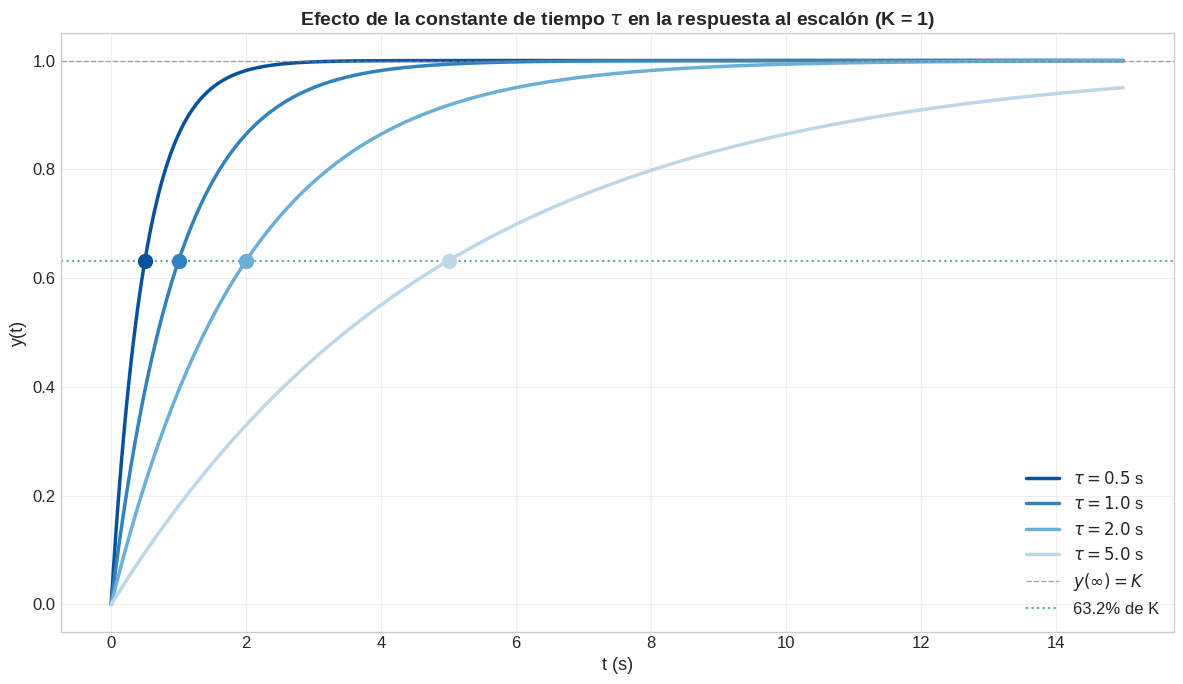

In [5]:
# PLOT 4: Efecto de τ en primer orden (4 curvas)
fig, ax = plt.subplots(figsize=(12, 7))

t = np.linspace(0, 15, 500)
K = 1.0
taus = [0.5, 1.0, 2.0, 5.0]
colores = ['#08519c', '#3182bd', '#6baed6', '#bdd7e7']

for tau, color in zip(taus, colores):
    sys_1 = signal.TransferFunction([K], [tau, 1])
    t_out, y_out = signal.step(sys_1, T=t)
    ax.plot(t_out, y_out, color=color, lw=2.5, label=rf'$\tau = {tau}$ s')
    # Marcar τ en cada curva
    y_tau = K * (1 - np.exp(-1))
    ax.plot(tau, y_tau, 'o', color=color, ms=10, zorder=5)

ax.axhline(K, color='gray', ls='--', lw=1, alpha=0.7, label=r'$y(\infty) = K$')
ax.axhline(K * 0.632, color=COLOR_PUNTO, ls=':', lw=1.5, alpha=0.7, label='63.2% de K')

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Efecto de la constante de tiempo $\tau$ en la respuesta al escalón (K = 1)',
             fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

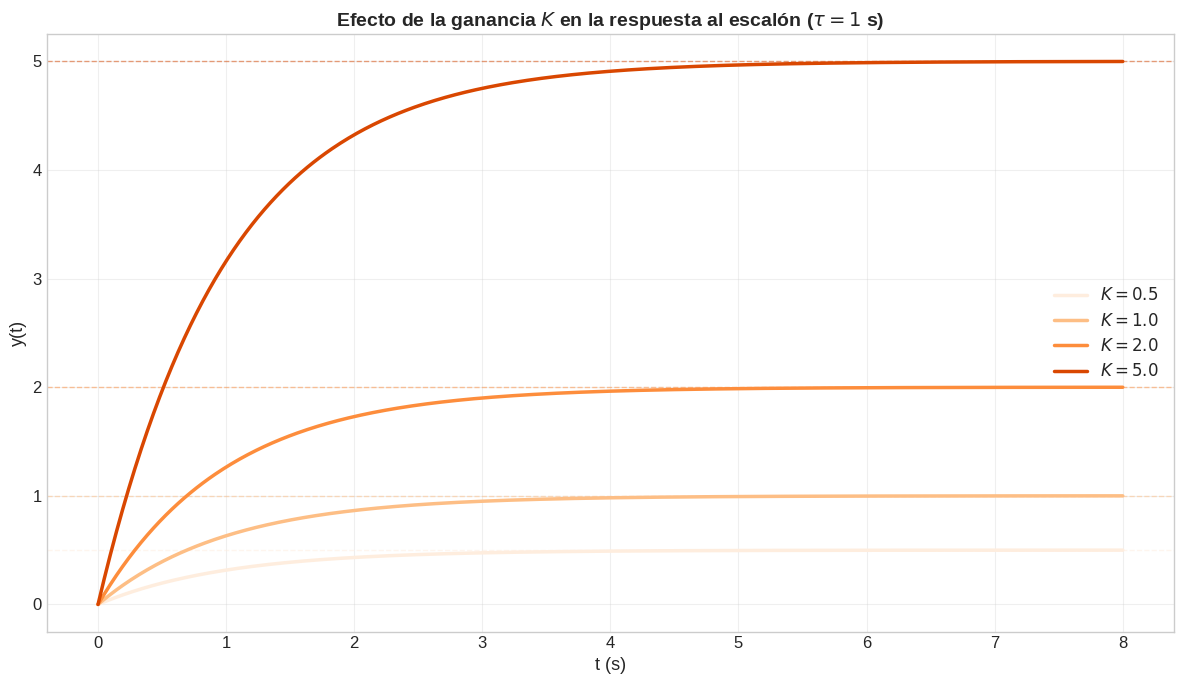

In [6]:
# PLOT 5: Efecto de K en primer orden (4 curvas)
fig, ax = plt.subplots(figsize=(12, 7))

t = np.linspace(0, 8, 500)
tau = 1.0
Ks = [0.5, 1.0, 2.0, 5.0]
colores_k = ['#feedde', '#fdbe85', '#fd8d3c', '#d94701']

for K_val, color in zip(Ks, colores_k):
    sys_1 = signal.TransferFunction([K_val], [tau, 1])
    t_out, y_out = signal.step(sys_1, T=t)
    ax.plot(t_out, y_out, color=color, lw=2.5, label=rf'$K = {K_val}$')
    ax.axhline(K_val, color=color, ls='--', lw=1, alpha=0.5)

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Efecto de la ganancia $K$ en la respuesta al escalón ($\tau = 1$ s)',
             fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Respuesta al impulso de primer orden

La respuesta al impulso de un sistema de primer orden es la derivada de la respuesta al escalón:

$$\boxed{h(t) = \frac{K}{\tau} e^{-t/\tau}, \quad t \geq 0}$$

La pendiente inicial de la respuesta al escalón es $y'(0^+) = K/\tau$, lo que coincide con $h(0^+)$.

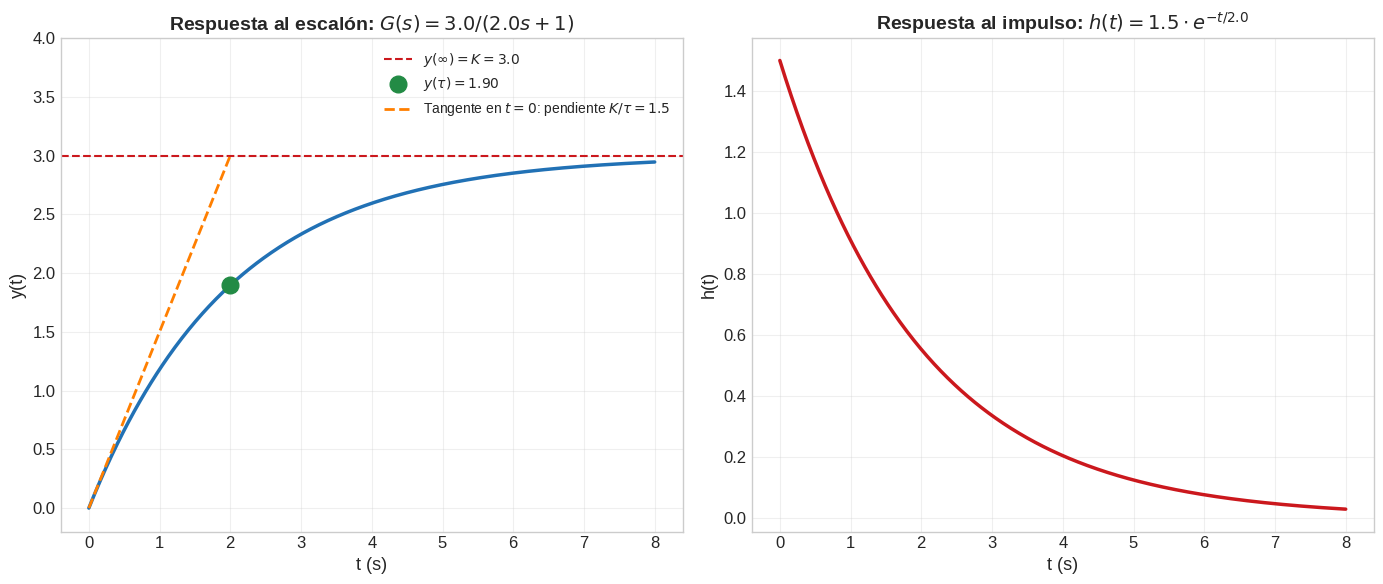

In [7]:
# PLOT adicional: Respuesta al escalón e impulso de 1er orden (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

t = np.linspace(0, 8, 500)
K, tau = 3.0, 2.0

# Escalón
sys_1 = signal.TransferFunction([K], [tau, 1])
t_step, y_step = signal.step(sys_1, T=t)
ax = axes[0]
ax.plot(t_step, y_step, color=COLOR_PRINCIPAL, lw=2.5)
ax.axhline(K, color=COLOR_RECTA, ls='--', lw=1.5, label=rf'$y(\infty) = K = {K}$')
ax.plot(tau, K * 0.632, 'o', color=COLOR_PUNTO, ms=12, zorder=5, label=rf'$y(\tau) = {K*0.632:.2f}$')
# Tangente en t=0
pendiente = K / tau
ax.plot([0, tau], [0, pendiente * tau], '--', color=COLOR_TRANS, lw=2,
        label=rf'Tangente en $t=0$: pendiente $K/\tau = {pendiente:.1f}$')
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(rf'Respuesta al escalón: $G(s) = {K}/({tau}s+1)$', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.2, 4)

# Impulso
t_imp, y_imp = signal.impulse(sys_1, T=t)
ax = axes[1]
ax.plot(t_imp, y_imp, color=COLOR_RECTA, lw=2.5)
ax.set_xlabel('t (s)')
ax.set_ylabel('h(t)')
ax.set_title(rf'Respuesta al impulso: $h(t) = {K/tau:.1f} \cdot e^{{-t/{tau}}}$', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Ejemplo resuelto: Primer orden

#### Ejercicio resuelto: Respuesta al escalón de $G(s) = \dfrac{3}{2s+1}$

**Datos:** $G(s) = \dfrac{3}{2s+1}$

**Paso 1:** Identificar parámetros comparando con la forma estándar $\dfrac{K}{\tau s + 1}$:

$$K = 3, \qquad \tau = 2 \;\text{s}$$

**Paso 2:** Valor final de la respuesta al escalón unitario:

$$y(\infty) = K = 3$$

**Paso 3:** Respuesta temporal:

$$y(t) = 3\left(1 - e^{-t/2}\right)$$

**Paso 4:** Valor en $t = 1$ s:

$$y(1) = 3\left(1 - e^{-1/2}\right) = 3\left(1 - 0.6065\right) = 3 \times 0.3935 = 1.18$$

**Paso 5:** Tiempo de establecimiento al $2\%$:

$$\boxed{t_s \approx 4\tau = 4 \times 2 = 8\;\text{s}}$$

**Paso 6:** Verificación de valores clave:
- $y(\tau) = y(2) = 3 \times 0.632 = 1.896$
- $y(3\tau) = y(6) = 3 \times 0.950 = 2.850$
- $y(5\tau) = y(10) = 3 \times 0.993 = 2.980$

---

## 5. Sistemas de segundo orden

### 5.1 Función de transferencia estándar

$$\boxed{G(s) = \frac{K\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}}$$

donde:
- $K$ = **ganancia estática** (valor final)
- $\omega_n$ = **frecuencia natural no amortiguada** (rad/s)
- $\zeta$ = **factor de amortiguamiento** (adimensional)

### 5.2 Clasificación según $\zeta$

| Rango de $\zeta$ | Tipo | Polos | Comportamiento |
|-------------------|------|-------|----------------|
| $\zeta = 0$ | No amortiguado | Imaginarios puros | Oscila indefinidamente |
| $0 < \zeta < 1$ | **Subamortiguado** | Complejos conjugados | Oscilaciones amortiguadas (caso más frecuente en exámenes) |
| $\zeta = 1$ | Críticamente amortiguado | Reales dobles | El más rápido sin sobrepaso |
| $\zeta > 1$ | Sobreamortiguado | Reales distintos | Sin oscilaciones, lento |

### 5.3 Fórmulas clave (caso subamortiguado $0 < \zeta < 1$)

$$\boxed{SO\% = e^{-\pi\zeta / \sqrt{1-\zeta^2}} \cdot 100}$$

$$\boxed{t_s \approx \frac{4}{\zeta\omega_n} \quad (\text{criterio } 2\%)}$$

$$\boxed{\omega_d = \omega_n\sqrt{1-\zeta^2}}$$

$$\boxed{t_r \approx \frac{\pi - \arccos(\zeta)}{\omega_d}}$$

$$\boxed{t_p = \frac{\pi}{\omega_d}}$$

### 5.4 Polos del sistema

$$s_{1,2} = -\zeta\omega_n \pm j\omega_n\sqrt{1-\zeta^2} = -\sigma \pm j\omega_d$$

donde $\sigma = \zeta\omega_n$ es la **parte real** (tasa de decaimiento) y $\omega_d$ es la **frecuencia de oscilación amortiguada**.

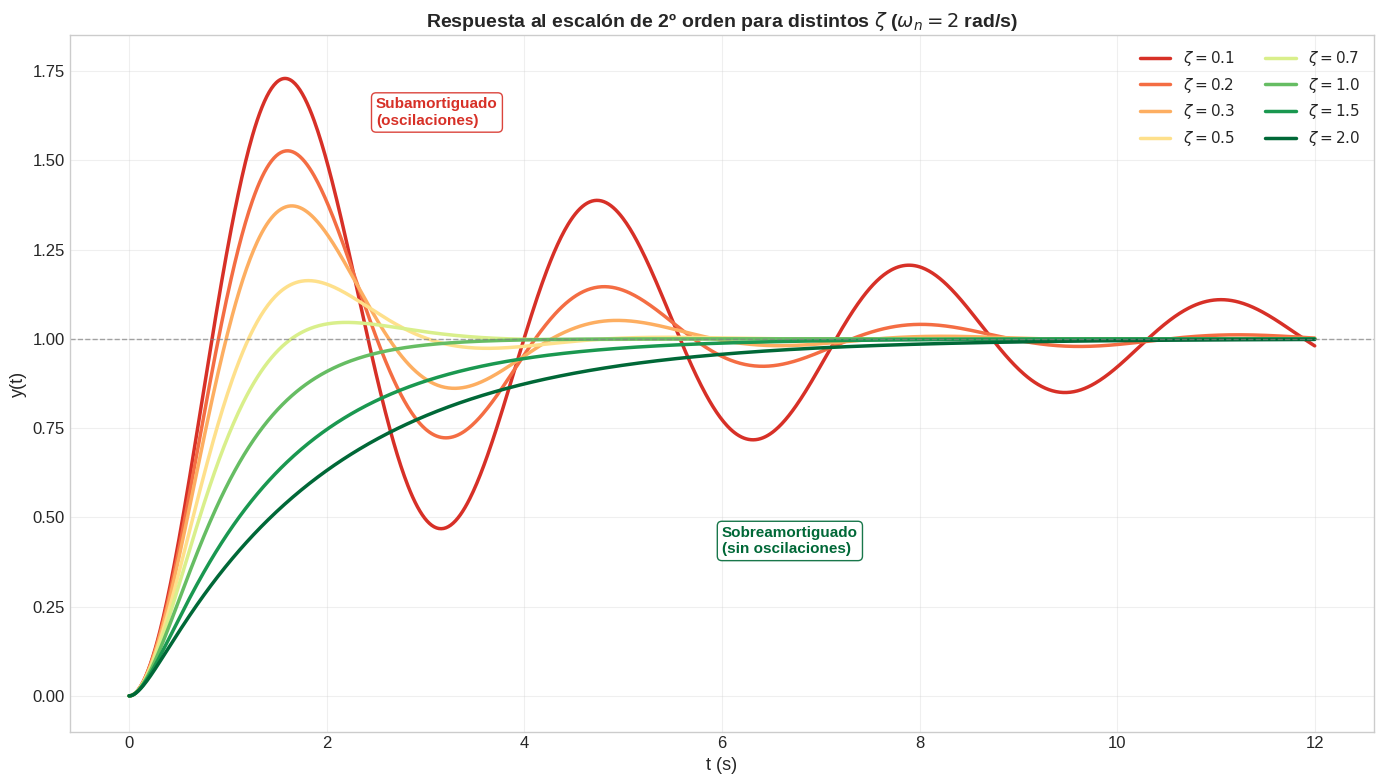

In [8]:
# PLOT 6: Familia de respuestas al escalón para distintos ζ (8 curvas)
fig, ax = plt.subplots(figsize=(14, 8))

t = np.linspace(0, 12, 1000)
wn = 2.0
zetas = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
colores_z = ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#d9ef8b', '#66bd63', '#1a9850', '#006837']

for zeta_val, color in zip(zetas, colores_z):
    sys_2 = signal.TransferFunction([wn**2], [1, 2 * zeta_val * wn, wn**2])
    t_out, y_out = signal.step(sys_2, T=t)
    ax.plot(t_out, y_out, color=color, lw=2.5, label=rf'$\zeta = {zeta_val}$')

ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.7)
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Respuesta al escalón de 2º orden para distintos $\zeta$ ($\omega_n = 2$ rad/s)',
             fontweight='bold')
ax.legend(fontsize=11, loc='upper right', ncol=2)
ax.set_ylim(-0.1, 1.85)
ax.grid(True, alpha=0.3)

# Anotar zonas
ax.annotate('Subamortiguado\n(oscilaciones)', xy=(2.5, 1.6),
            fontsize=11, color='#d73027', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#d73027', alpha=0.9))
ax.annotate('Sobreamortiguado\n(sin oscilaciones)', xy=(6, 0.4),
            fontsize=11, color='#006837', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#006837', alpha=0.9))

plt.tight_layout()
plt.show()

### 5.5 Efecto de $\omega_n$ (con $\zeta$ fijo)

Mientras que $\zeta$ controla la **forma** de la respuesta (cuánto oscila), $\omega_n$ controla la **velocidad** (cuán rápido responde). A mayor $\omega_n$, menor $t_s$ y menor $t_r$, pero el SO% no cambia.

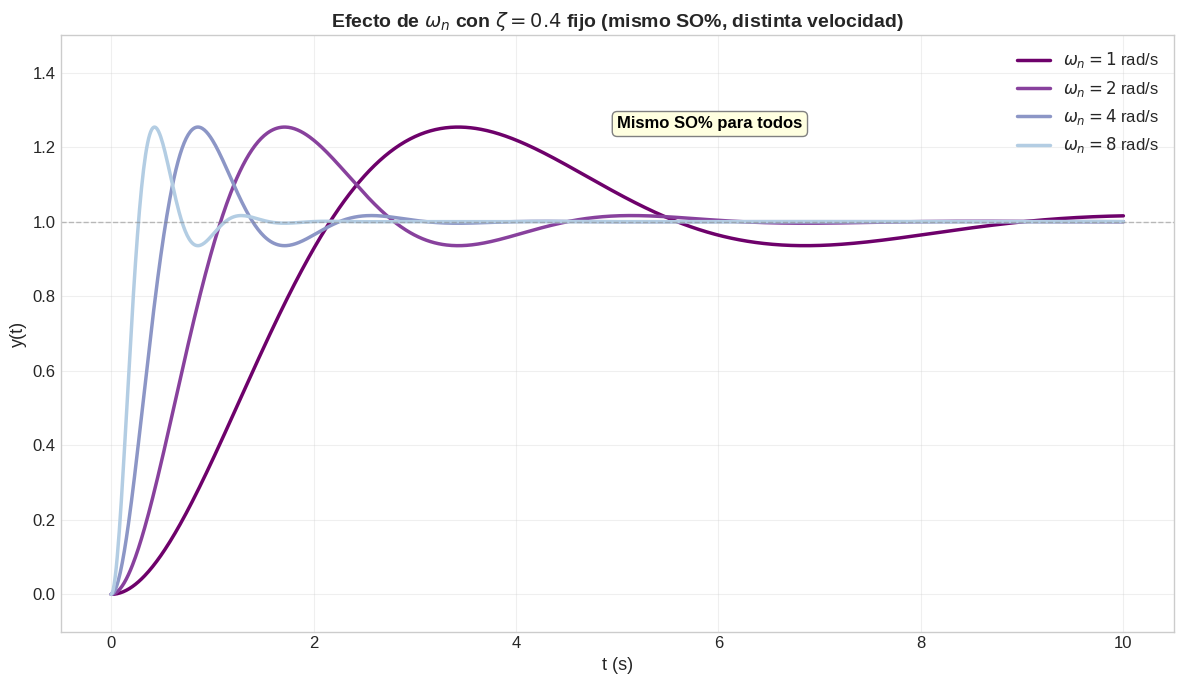

In [9]:
# PLOT adicional: Efecto de ωn con ζ fijo
fig, ax = plt.subplots(figsize=(12, 7))

t = np.linspace(0, 10, 1000)
zeta = 0.4
wn_vals = [1, 2, 4, 8]
colores_wn = ['#6e016b', '#88419d', '#8c96c6', '#b3cde3']

for wn_val, color in zip(wn_vals, colores_wn):
    sys_wn = signal.TransferFunction([wn_val**2], [1, 2 * zeta * wn_val, wn_val**2])
    t_out, y_out = signal.step(sys_wn, T=t)
    ax.plot(t_out, y_out, color=color, lw=2.5, label=rf'$\omega_n = {wn_val}$ rad/s')

ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Efecto de $\omega_n$ con $\zeta = 0.4$ fijo (mismo SO%, distinta velocidad)',
             fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.5)

ax.annotate(r'Mismo SO% para todos', xy=(5, 1.25),
            fontsize=12, color='black', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

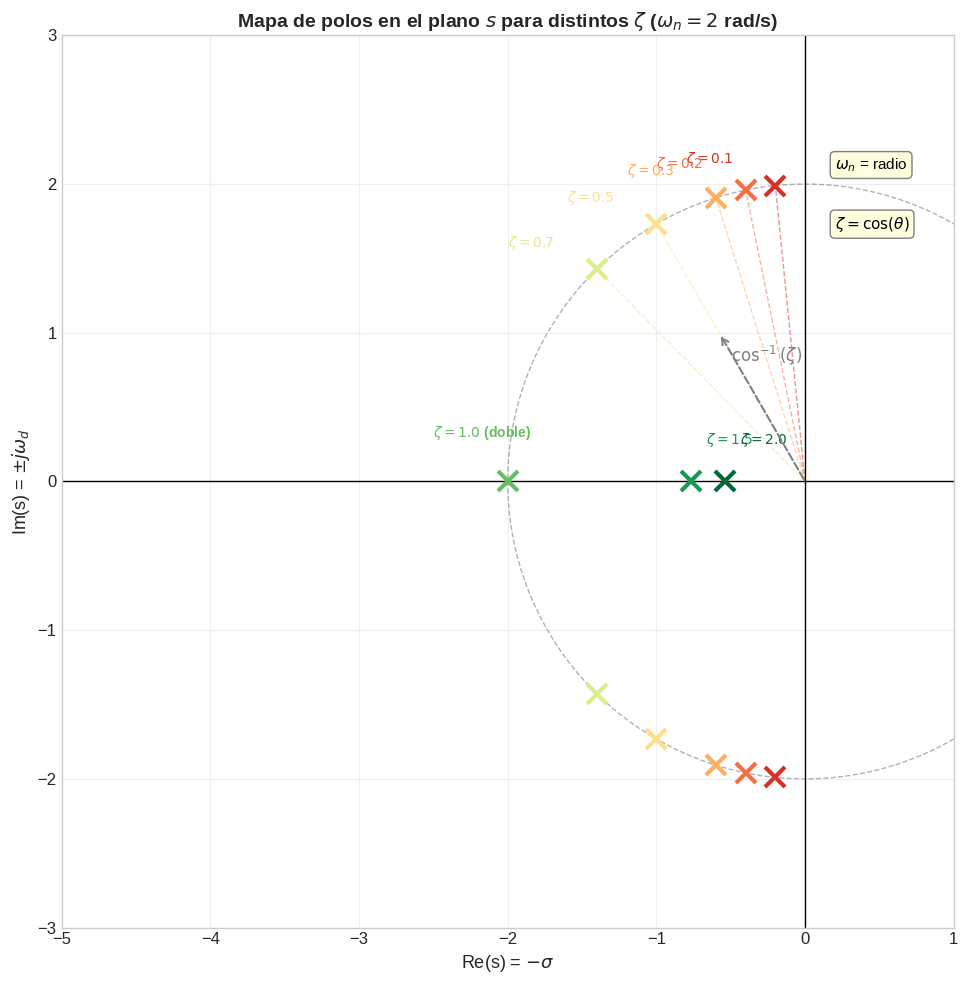

In [10]:
# PLOT 7: Mapa de polos en el plano s para distintos ζ
fig, ax = plt.subplots(figsize=(10, 10))

wn = 2.0
zetas = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
colores_z = ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#d9ef8b', '#66bd63', '#1a9850', '#006837']

# Dibujar circunferencia de radio ωn
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(wn * np.cos(theta), wn * np.sin(theta), 'k--', lw=1, alpha=0.3, label=rf'$\omega_n = {wn}$')

for zeta_val, color in zip(zetas, colores_z):
    if zeta_val < 1:
        sigma = -zeta_val * wn
        wd = wn * np.sqrt(1 - zeta_val**2)
        ax.plot(sigma, wd, 'x', color=color, ms=14, mew=3, zorder=5)
        ax.plot(sigma, -wd, 'x', color=color, ms=14, mew=3, zorder=5)
        ax.annotate(rf'$\zeta={zeta_val}$', xy=(sigma, wd),
                    xytext=(sigma - 0.6, wd + 0.15), fontsize=10, color=color, fontweight='bold')
        # Línea desde origen al polo
        ax.plot([0, sigma], [0, wd], '--', color=color, lw=1, alpha=0.5)
    elif zeta_val == 1:
        ax.plot(-wn, 0, 'x', color=color, ms=14, mew=3, zorder=5)
        ax.annotate(rf'$\zeta={zeta_val}$ (doble)', xy=(-wn, 0),
                    xytext=(-wn - 0.5, 0.3), fontsize=10, color=color, fontweight='bold')
    else:
        s1 = -zeta_val * wn + wn * np.sqrt(zeta_val**2 - 1)
        s2 = -zeta_val * wn - wn * np.sqrt(zeta_val**2 - 1)
        ax.plot(s1, 0, 'x', color=color, ms=14, mew=3, zorder=5)
        ax.plot(s2, 0, 'x', color=color, ms=14, mew=3, zorder=5)
        ax.annotate(rf'$\zeta={zeta_val}$', xy=(s1, 0),
                    xytext=(s1 + 0.1, 0.25), fontsize=10, color=color, fontweight='bold')

# Ejes
ax.axhline(0, color='k', lw=1)
ax.axvline(0, color='k', lw=1)

# Anotar ángulo ζ
angle = np.arccos(0.5)
r_line = wn * 1.15
ax.annotate('', xy=(-r_line * np.cos(angle) * 0.5, r_line * np.sin(angle) * 0.5),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))
ax.annotate(r'$\cos^{-1}(\zeta)$', xy=(-0.5, 0.8), fontsize=12, color='gray')

ax.set_xlabel(r'Re(s) = $-\sigma$')
ax.set_ylabel(r'Im(s) = $\pm j\omega_d$')
ax.set_title(r'Mapa de polos en el plano $s$ para distintos $\zeta$ ($\omega_n = 2$ rad/s)',
             fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(-5, 1)
ax.set_ylim(-3, 3)
ax.grid(True, alpha=0.3)

# Anotar relación geométrica
ax.annotate(r'$\omega_n$ = radio', xy=(0.2, 2.1), fontsize=11, color='black',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
ax.annotate(r'$\zeta = \cos(\theta)$', xy=(0.2, 1.7), fontsize=11, color='black',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
plt.show()

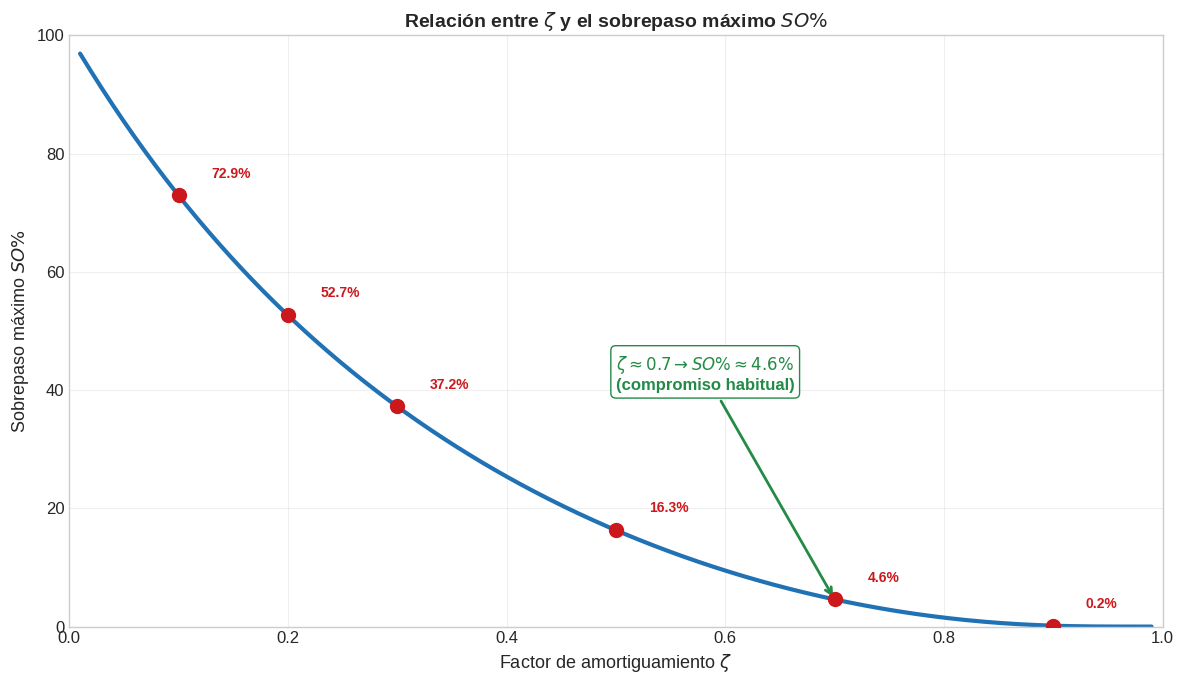

In [11]:
# PLOT 8: SO% vs ζ
fig, ax = plt.subplots(figsize=(12, 7))

zeta_range = np.linspace(0.01, 0.99, 500)
SO_range = np.exp(-np.pi * zeta_range / np.sqrt(1 - zeta_range**2)) * 100

ax.plot(zeta_range, SO_range, color=COLOR_PRINCIPAL, lw=3)

# Marcar puntos clave
puntos_zeta = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
for z in puntos_zeta:
    so = np.exp(-np.pi * z / np.sqrt(1 - z**2)) * 100
    ax.plot(z, so, 'o', color=COLOR_RECTA, ms=10, zorder=5)
    ax.annotate(f'{so:.1f}%', xy=(z, so), xytext=(z + 0.03, so + 3),
                fontsize=10, color=COLOR_RECTA, fontweight='bold')

ax.set_xlabel(r'Factor de amortiguamiento $\zeta$')
ax.set_ylabel(r'Sobrepaso máximo $SO\%$')
ax.set_title(r'Relación entre $\zeta$ y el sobrepaso máximo $SO\%$', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# Regla práctica
ax.annotate(r'$\zeta \approx 0.7 \to SO\% \approx 4.6\%$' + '\n(compromiso habitual)',
            xy=(0.7, 4.6), xytext=(0.5, 40), fontsize=12, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

plt.tight_layout()
plt.show()

**Observación importante sobre la gráfica SO% vs $\zeta$:**

- Para $\zeta = 0.1$: SO% $\approx 73\%$ (oscila mucho, inaceptable en la mayoría de aplicaciones)
- Para $\zeta = 0.5$: SO% $\approx 16\%$ (aceptable para muchas aplicaciones)
- Para $\zeta = 0.707$ ($= 1/\sqrt{2}$): SO% $\approx 4.3\%$ (compromiso óptimo velocidad/sobrepaso)
- Para $\zeta \geq 1$: SO% $= 0\%$ (sin oscilaciones, pero respuesta lenta)

**Truco para el examen:** Si te piden el valor de $\zeta$ que da SO% = $x$%, usa la fórmula inversa:

$$\boxed{\zeta = \frac{|\ln(SO/100)|}{\sqrt{\pi^2 + \ln^2(SO/100)}}}$$

### 5.5 Ejemplo resuelto: Segundo orden

#### Ejercicio resuelto: Análisis completo de $G(s) = \dfrac{9}{s^2 + 2.4s + 9}$

**Datos:** $G(s) = \dfrac{9}{s^2 + 2.4s + 9}$

**Paso 1:** Comparar con la forma estándar $\dfrac{K\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$:

$$\omega_n^2 = 9 \implies \boxed{\omega_n = 3\;\text{rad/s}}$$

$$2\zeta\omega_n = 2.4 \implies \zeta = \frac{2.4}{2 \times 3} = \boxed{\zeta = 0.4}$$

$$K\omega_n^2 = 9 \implies K = \frac{9}{9} = \boxed{K = 1}$$

**Paso 2:** Como $0 < \zeta = 0.4 < 1$, el sistema es **subamortiguado**.

**Paso 3:** Frecuencia amortiguada:

$$\omega_d = \omega_n\sqrt{1-\zeta^2} = 3\sqrt{1-0.16} = 3\sqrt{0.84} = 3 \times 0.9165 = \boxed{2.75\;\text{rad/s}}$$

**Paso 4:** Sobrepaso máximo:

$$SO\% = e^{-\pi \times 0.4 / \sqrt{1-0.16}} \times 100 = e^{-1.2566/0.9165} \times 100 = e^{-1.3714} \times 100 = \boxed{25.38\%}$$

**Paso 5:** Tiempo de establecimiento (criterio 2%):

$$t_s \approx \frac{4}{\zeta\omega_n} = \frac{4}{0.4 \times 3} = \frac{4}{1.2} = \boxed{3.33\;\text{s}}$$

**Paso 6:** Tiempo de subida:

$$t_r \approx \frac{\pi - \arccos(0.4)}{2.75} = \frac{3.1416 - 1.1593}{2.75} = \frac{1.9823}{2.75} = \boxed{0.72\;\text{s}}$$

**Paso 7:** Tiempo de pico:

$$t_p = \frac{\pi}{\omega_d} = \frac{3.1416}{2.75} = \boxed{1.14\;\text{s}}$$

**Paso 8:** Polos del sistema:

$$s_{1,2} = -0.4 \times 3 \pm j \times 2.75 = -1.2 \pm 2.75j$$

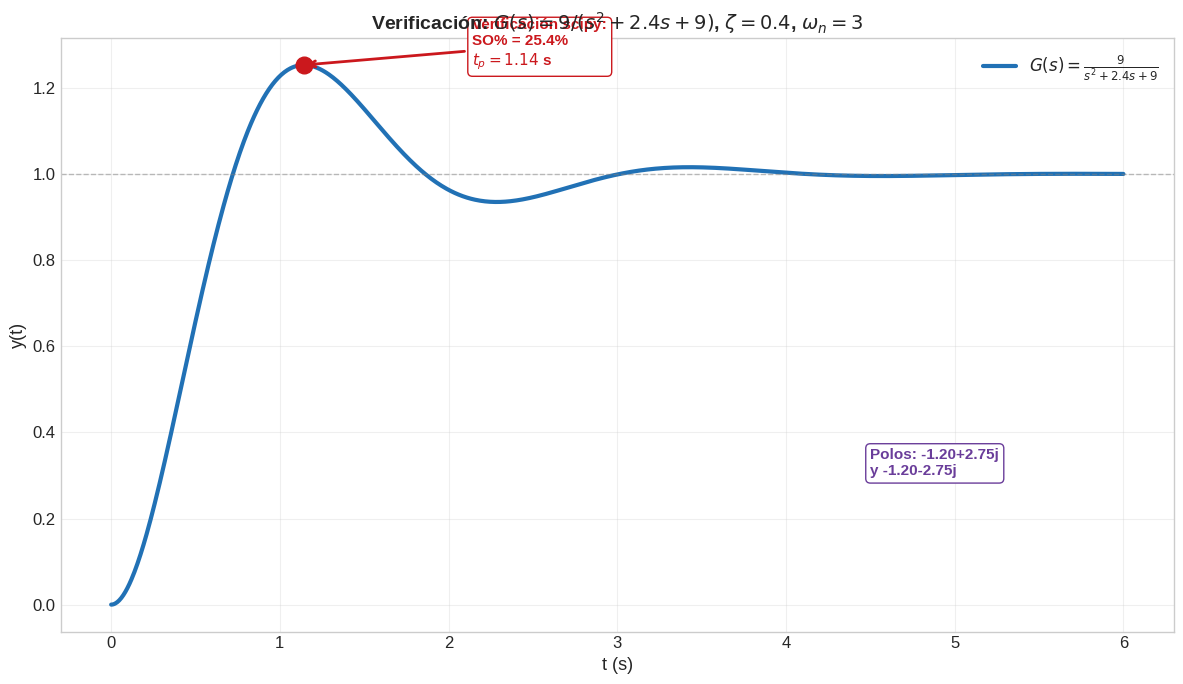

In [12]:
# PLOT adicional: Verificación del ejemplo resuelto de 2º orden con scipy
fig, ax = plt.subplots(figsize=(12, 7))

# G(s) = 9/(s²+2.4s+9) → ωn=3, ζ=0.4
sys_ej2 = signal.TransferFunction([9], [1, 2.4, 9])
t = np.linspace(0, 6, 1000)
t_out, y_out = signal.step(sys_ej2, T=t)

ax.plot(t_out, y_out, color=COLOR_PRINCIPAL, lw=3, label=r'$G(s) = \frac{9}{s^2+2.4s+9}$')
ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.5)

# Marcar parámetros calculados
y_max = np.max(y_out)
t_peak = t_out[np.argmax(y_out)]
SO_calc = (y_max - 1) * 100

ax.plot(t_peak, y_max, 'o', color=COLOR_RECTA, ms=12, zorder=5)
ax.annotate(f'Verificación scipy:\nSO% = {SO_calc:.1f}%\n$t_p = {t_peak:.2f}$ s',
            xy=(t_peak, y_max), xytext=(t_peak + 1, y_max),
            fontsize=11, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))

# Polos
polos = np.roots([1, 2.4, 9])
ax.annotate(f'Polos: {polos[0]:.2f}\ny {polos[1]:.2f}',
            xy=(4.5, 0.3), fontsize=11, color=COLOR_PERM, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PERM))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Verificación: $G(s) = 9/(s^2+2.4s+9)$, $\zeta=0.4$, $\omega_n=3$', fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 6. Sistemas de orden superior: polos dominantes

Cuando un sistema tiene más de 2 polos, su respuesta puede ser compleja. Sin embargo, si un par de polos está **mucho más cerca del eje imaginario** que los demás, esos son los **polos dominantes** y el sistema se comporta aproximadamente como uno de segundo orden.

**Regla práctica:** Un polo es dominante si los demás polos tienen parte real al menos **5 veces mayor** en valor absoluto.

$$\text{Si } |Re(p_{\text{lejano}})| \geq 5 \cdot |Re(p_{\text{dominante}})| \implies \text{se puede aproximar por 2º orden}$$

**Cómo afecta la posición de los polos al comportamiento:**

- Si **$\sigma$ (parte real) aumenta** $\to$ transitorio se extingue más rápido $\to$ $t_s$ disminuye
- Si **$\omega_d$ (parte imaginaria) aumenta** $\to$ frecuencia de oscilación mayor $\to$ oscila más rápido
- Si **polo se acerca al eje imaginario** $\to$ transitorio más lento $\to$ polo dominante
- Si **polo cruza al semiplano derecho** $\to$ sistema inestable $\to$ respuesta diverge

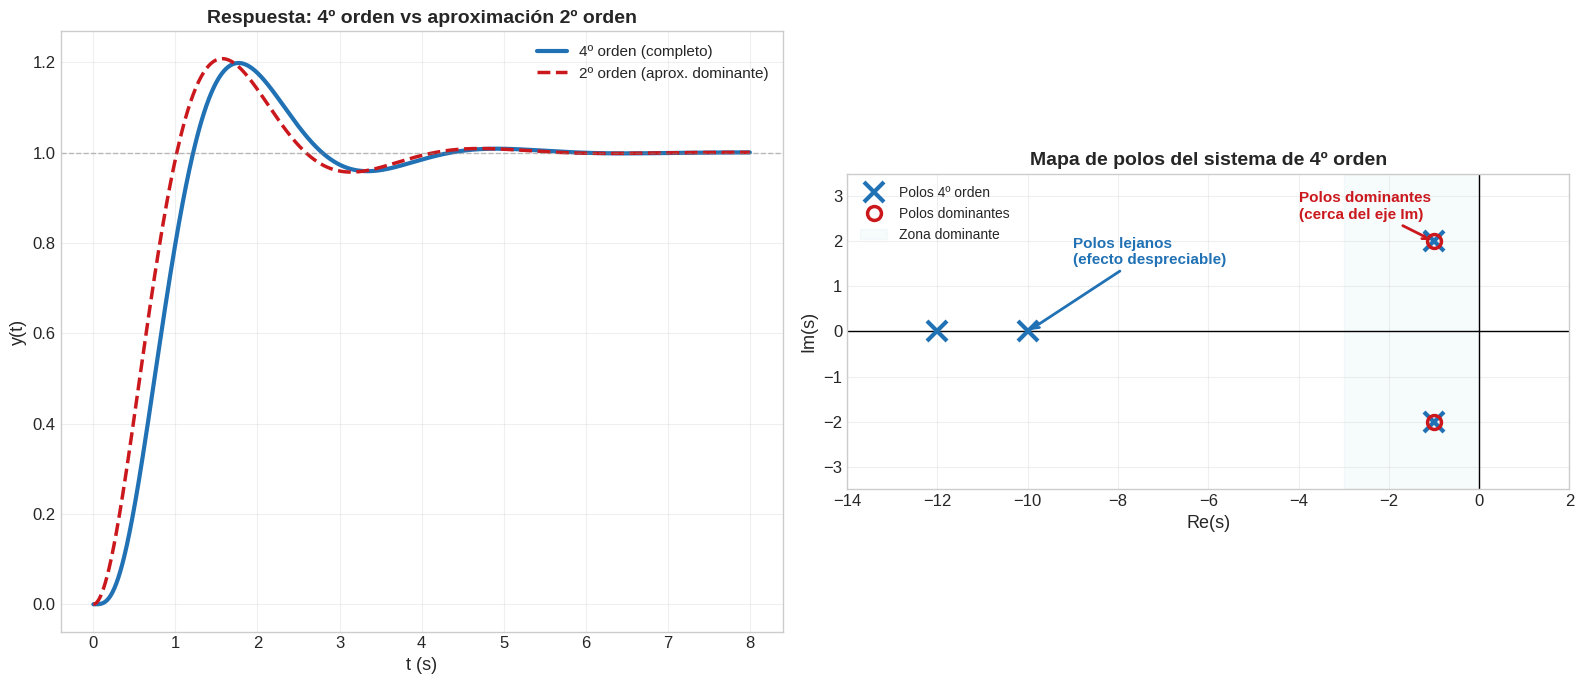

In [13]:
# PLOT 9: Sistema de 4º orden vs aproximación de 2º orden (polos dominantes)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sistema de 4º orden: polos dominantes en -1±2j, polos lejanos en -10, -12
# G(s) = K * wn^2 / [(s+10)(s+12)(s^2+2s+5)]
num_4 = [1.0]
den_dom = [1, 2, 5]       # s^2+2s+5 → polos en -1±2j
den_lej = np.polymul([1, 10], [1, 12])  # (s+10)(s+12)
den_4 = np.polymul(den_dom, den_lej)

# Normalizar para ganancia estática = 1
K_4 = np.polyval(den_4, 0)
num_4 = [K_4]

sys_4 = signal.TransferFunction(num_4, den_4)
t = np.linspace(0, 8, 1000)
t4, y4 = signal.step(sys_4, T=t)

# Aproximación de 2º orden (solo polos dominantes)
K_2_approx = np.polyval(den_dom, 0)
sys_2_approx = signal.TransferFunction([K_2_approx], den_dom)
t2, y2 = signal.step(sys_2_approx, T=t)

# Respuestas
ax = axes[0]
ax.plot(t4, y4, color=COLOR_PRINCIPAL, lw=3, label=r'4º orden (completo)')
ax.plot(t2, y2, '--', color=COLOR_RECTA, lw=2.5, label=r'2º orden (aprox. dominante)')
ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Respuesta: 4º orden vs aproximación 2º orden', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Mapa de polos
ax = axes[1]
polos_4 = np.roots(den_4)
polos_2 = np.roots(den_dom)

ax.plot(np.real(polos_4), np.imag(polos_4), 'x', color=COLOR_PRINCIPAL, ms=14, mew=3,
        label='Polos 4º orden', zorder=5)
ax.plot(np.real(polos_2), np.imag(polos_2), 'o', color=COLOR_RECTA, ms=10, mfc='none', mew=2.5,
        label='Polos dominantes', zorder=5)

ax.axhline(0, color='k', lw=1)
ax.axvline(0, color='k', lw=1)

# Zona dominante
ax.axvspan(-3, 0, alpha=0.1, color='lightblue', label='Zona dominante')

ax.annotate('Polos dominantes\n(cerca del eje Im)', xy=(-1, 2),
            xytext=(-4, 2.5), fontsize=11, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2))
ax.annotate('Polos lejanos\n(efecto despreciable)', xy=(-10, 0),
            xytext=(-9, 1.5), fontsize=11, color=COLOR_PRINCIPAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2))

ax.set_xlabel(r'Re(s)')
ax.set_ylabel(r'Im(s)')
ax.set_title('Mapa de polos del sistema de 4º orden', fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
ax.set_xlim(-14, 2)
ax.set_ylim(-3.5, 3.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 7. Estabilidad

### 7.1 Condición de estabilidad

Un sistema LTI es **estable** si y solo si **todos** sus polos tienen parte real negativa (están en el semiplano izquierdo del plano $s$):

$$\boxed{\text{Estable} \iff Re(p_i) < 0 \quad \forall i}$$

| Ubicación de polos | Comportamiento |
|---------------------|----------------|
| Todos en semiplano izquierdo ($Re < 0$) | **Estable** |
| Alguno en eje imaginario ($Re = 0$) | **Marginalmente estable** (oscilación permanente) |
| Alguno en semiplano derecho ($Re > 0$) | **Inestable** (respuesta divergente) |

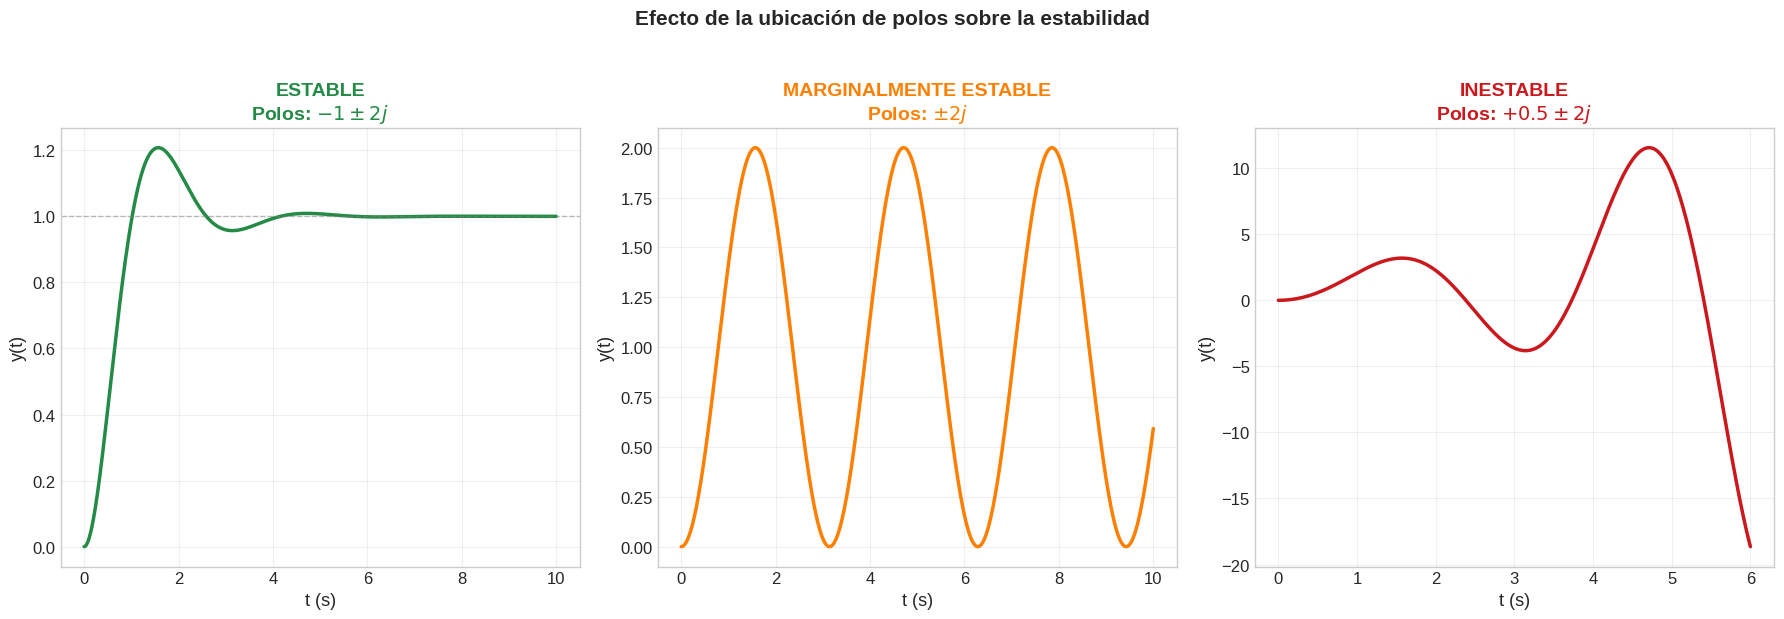

In [14]:
# PLOT 10: Estable vs marginalmente estable vs inestable
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

t = np.linspace(0, 10, 1000)

# Estable: polos en -1±2j
sys_est = signal.TransferFunction([5], [1, 2, 5])
t1, y1 = signal.step(sys_est, T=t)
ax = axes[0]
ax.plot(t1, y1, color=COLOR_PUNTO, lw=2.5)
ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_title('ESTABLE\nPolos: $-1 \\pm 2j$', fontweight='bold', color=COLOR_PUNTO)
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.grid(True, alpha=0.3)

# Marginalmente estable: polos en ±2j
sys_marg = signal.TransferFunction([4], [1, 0, 4])
t2, y2 = signal.step(sys_marg, T=t)
ax = axes[1]
ax.plot(t2, y2, color=COLOR_TRANS, lw=2.5)
ax.set_title('MARGINALMENTE ESTABLE\nPolos: $\\pm 2j$', fontweight='bold', color=COLOR_TRANS)
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.grid(True, alpha=0.3)

# Inestable: polos en +0.5±2j
sys_inst = signal.TransferFunction([4.25], [1, -1, 4.25])
t3 = np.linspace(0, 6, 500)
t3_out, y3 = signal.step(sys_inst, T=t3)
ax = axes[2]
ax.plot(t3_out, y3, color=COLOR_RECTA, lw=2.5)
ax.set_title('INESTABLE\nPolos: $+0.5 \\pm 2j$', fontweight='bold', color=COLOR_RECTA)
ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.grid(True, alpha=0.3)

plt.suptitle('Efecto de la ubicación de polos sobre la estabilidad',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

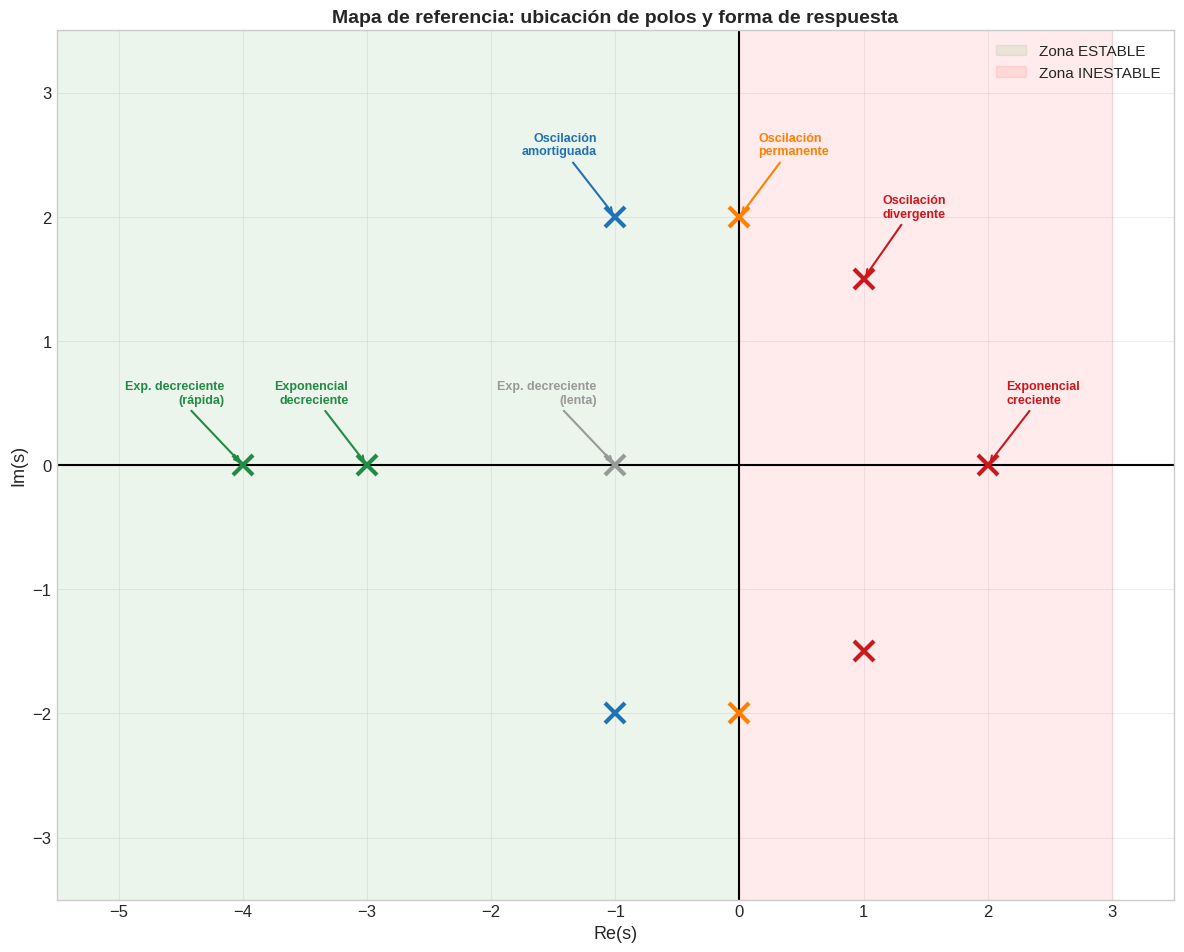

In [15]:
# PLOT adicional: Mapa completo de ubicaciones de polos y formas de respuesta
fig, ax = plt.subplots(figsize=(12, 10))

# Ejes
ax.axhline(0, color='k', lw=1.5)
ax.axvline(0, color='k', lw=1.5)

# Zona estable (sombreada)
ax.axvspan(-6, 0, alpha=0.08, color='green', label='Zona ESTABLE')
ax.axvspan(0, 3, alpha=0.08, color='red', label='Zona INESTABLE')

# Polos de ejemplo con minigráficas descriptivas
casos = [
    (-3, 0, 'Exponencial\ndecreciente', COLOR_PUNTO),
    (-1, 2, 'Oscilación\namortiguada', COLOR_PRINCIPAL),
    (-1, -2, '', COLOR_PRINCIPAL),
    (0, 2, 'Oscilación\npermanente', COLOR_TRANS),
    (0, -2, '', COLOR_TRANS),
    (1, 1.5, 'Oscilación\ndivergente', COLOR_RECTA),
    (1, -1.5, '', COLOR_RECTA),
    (2, 0, 'Exponencial\ncreciente', COLOR_RECTA),
    (-4, 0, 'Exp. decreciente\n(rápida)', COLOR_PUNTO),
    (-1, 0, 'Exp. decreciente\n(lenta)', '#999999'),
]

for re_s, im_s, label, color in casos:
    ax.plot(re_s, im_s, 'x', color=color, ms=14, mew=3, zorder=5)
    if label:
        offset_x = 0.15 if re_s >= 0 else -0.15
        ha = 'left' if re_s >= 0 else 'right'
        ax.annotate(label, xy=(re_s, im_s),
                    xytext=(re_s + offset_x, im_s + 0.5),
                    fontsize=9, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
                    ha=ha)

ax.set_xlabel(r'Re(s)', fontsize=13)
ax.set_ylabel(r'Im(s)', fontsize=13)
ax.set_title('Mapa de referencia: ubicación de polos y forma de respuesta', fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim(-5.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Criterio de Routh-Hurwitz

El criterio de Routh-Hurwitz permite determinar la estabilidad **sin calcular las raíces** del polinomio característico. Se construye una **tabla de Routh** a partir de los coeficientes.

Para un polinomio $a_n s^n + a_{n-1} s^{n-1} + \cdots + a_1 s + a_0$:

**Condición necesaria:** Todos los coeficientes deben tener el **mismo signo** y ser **no nulos**.

**Condición necesaria y suficiente:** Todos los elementos de la **primera columna** de la tabla de Routh deben ser **positivos** (o todos negativos).

### Construcción de la tabla de Routh

Para $a_3 s^3 + a_2 s^2 + a_1 s + a_0$:

| Fila | $s^3$ | $s^2$ | $s^1$ | $s^0$ |
|------|-------|-------|-------|-------|
| $s^3$ | $a_3$ | $a_1$ | | |
| $s^2$ | $a_2$ | $a_0$ | | |
| $s^1$ | $b_1$ | | | |
| $s^0$ | $c_1$ | | | |

donde:

$$b_1 = \frac{a_2 \cdot a_1 - a_3 \cdot a_0}{a_2}, \qquad c_1 = a_0$$

**El número de cambios de signo** en la primera columna = número de polos en el semiplano derecho.

### Casos especiales de la tabla de Routh

**Caso 1: Cero en la primera columna**

Si aparece un $0$ en la primera columna (pero la fila no es toda ceros), se sustituye por $\varepsilon$ (épsilon positivo pequeño) y se continúa. Al final, se toma $\varepsilon \to 0^+$.

**Caso 2: Fila de ceros completa**

Si una fila completa es cero, indica que hay polos simétricos respecto al origen (en el eje imaginario o simétricos en el eje real). Se construye un **polinomio auxiliar** con la fila anterior, se deriva y se usa como nueva fila.

**Error frecuente:** Olvidar que el criterio cuenta cambios de signo, no simplemente si hay negativos. $\{+, +, -, -\}$ tiene **1 cambio** de signo (no 2).

#### Ejercicio resuelto: Estabilidad de $s^3 + 6s^2 + 11s + 6 = 0$

**Datos:** Polinomio característico $s^3 + 6s^2 + 11s + 6 = 0$

**Paso 1:** Verificar condición necesaria: todos los coeficientes son positivos (1, 6, 11, 6). OK.

**Paso 2:** Construir la tabla de Routh:

| Fila | Col 1 | Col 2 |
|------|-------|-------|
| $s^3$ | $1$ | $11$ |
| $s^2$ | $6$ | $6$ |
| $s^1$ | $b_1$ | |
| $s^0$ | $c_1$ | |

$$b_1 = \frac{6 \times 11 - 1 \times 6}{6} = \frac{66 - 6}{6} = \frac{60}{6} = 10$$

$$c_1 = 6$$

**Paso 3:** Primera columna: $\{1, 6, 10, 6\}$. Todos positivos $\to$ **0 cambios de signo**.

$$\boxed{\text{El sistema es ESTABLE (3 polos con } Re < 0\text{)}}$$

**Verificación:** Las raíces son $s = -1, -2, -3$ (todas negativas, confirma estabilidad).

#### Ejercicio resuelto: Rango de $K$ para estabilidad de $s^3 + 3s^2 + 2s + K = 0$

**Datos:** Polinomio característico $s^3 + 3s^2 + 2s + K = 0$, encontrar rango de $K$ para estabilidad.

**Paso 1:** Condición necesaria: todos los coeficientes del mismo signo $\to K > 0$.

**Paso 2:** Tabla de Routh:

| Fila | Col 1 | Col 2 |
|------|-------|-------|
| $s^3$ | $1$ | $2$ |
| $s^2$ | $3$ | $K$ |
| $s^1$ | $b_1$ | |
| $s^0$ | $c_1$ | |

$$b_1 = \frac{3 \times 2 - 1 \times K}{3} = \frac{6 - K}{3}$$

$$c_1 = K$$

**Paso 3:** Para estabilidad, toda la primera columna debe ser positiva:

- $1 > 0$ (siempre)
- $3 > 0$ (siempre)
- $b_1 > 0 \implies \dfrac{6-K}{3} > 0 \implies K < 6$
- $c_1 > 0 \implies K > 0$

$$\boxed{0 < K < 6}$$

**Truco para el examen:** La fila $s^1$ siempre da la condición superior y la fila $s^0$ da la condición inferior. Si $K = 6$, el sistema es marginalmente estable (polos en el eje imaginario).

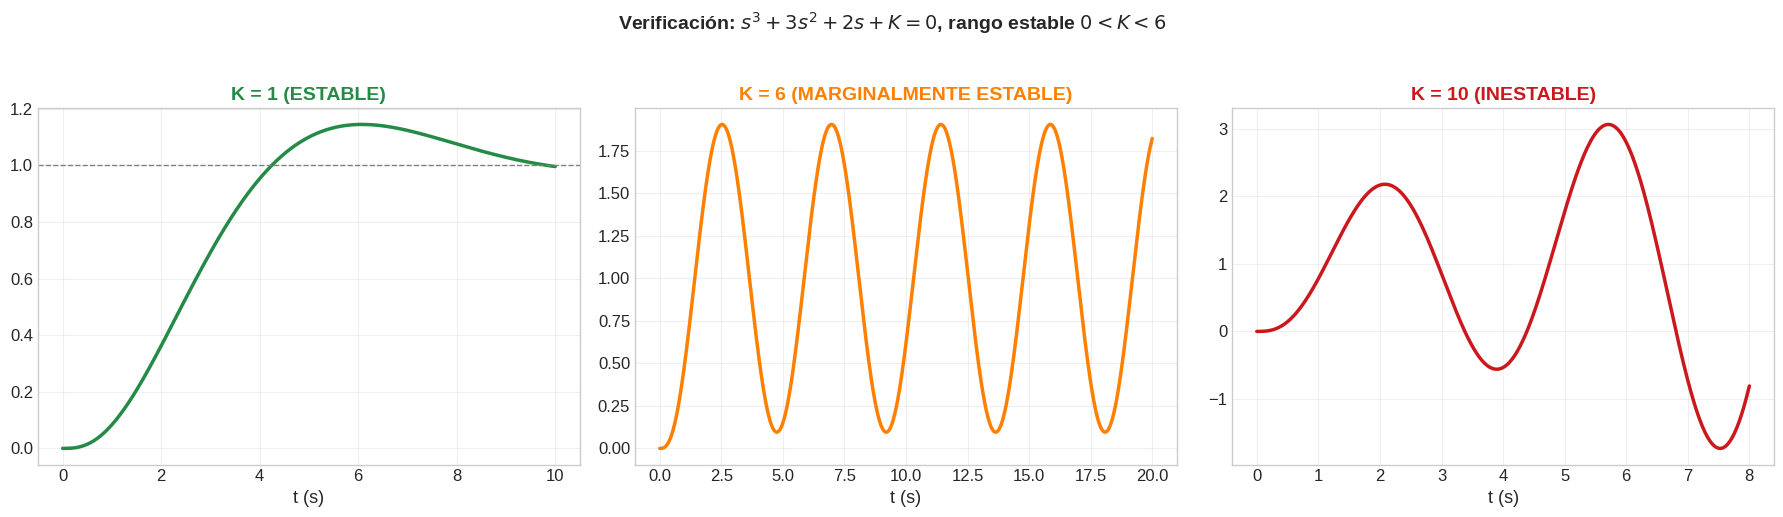

In [16]:
# PLOT adicional: Verificación rango de K con respuestas al escalón
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

t = np.linspace(0, 10, 500)

# K=1 (estable)
K_val = 1
sys_k1 = signal.TransferFunction([K_val], [1, 3, 2, K_val])
t1, y1 = signal.step(sys_k1, T=t)
axes[0].plot(t1, y1, color=COLOR_PUNTO, lw=2.5)
axes[0].set_title(f'K = {K_val} (ESTABLE)', fontweight='bold', color=COLOR_PUNTO)
axes[0].axhline(1, color='gray', ls='--', lw=1)
axes[0].set_xlabel('t (s)')
axes[0].grid(True, alpha=0.3)

# K=6 (marginalmente estable)
K_val = 6
sys_k6 = signal.TransferFunction([K_val], [1, 3, 2, K_val])
t2 = np.linspace(0, 20, 1000)
t2_out, y2 = signal.step(sys_k6, T=t2)
axes[1].plot(t2_out, y2, color=COLOR_TRANS, lw=2.5)
axes[1].set_title(f'K = {K_val} (MARGINALMENTE ESTABLE)', fontweight='bold', color=COLOR_TRANS)
axes[1].set_xlabel('t (s)')
axes[1].grid(True, alpha=0.3)

# K=10 (inestable)
K_val = 10
sys_k10 = signal.TransferFunction([K_val], [1, 3, 2, K_val])
t3 = np.linspace(0, 8, 500)
t3_out, y3 = signal.step(sys_k10, T=t3)
axes[2].plot(t3_out, y3, color=COLOR_RECTA, lw=2.5)
axes[2].set_title(f'K = {K_val} (INESTABLE)', fontweight='bold', color=COLOR_RECTA)
axes[2].set_xlabel('t (s)')
axes[2].grid(True, alpha=0.3)

plt.suptitle(r'Verificación: $s^3+3s^2+2s+K=0$, rango estable $0 < K < 6$',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---

## 8. Identificación de modelos desde respuesta experimental (*Black-box*)

### 8.1 Método para primer orden

Dado un registro experimental de respuesta al escalón de amplitud $A$:

1. **Ganancia estática:** $K = \dfrac{y(\infty)}{A}$
2. **Constante de tiempo** $\tau$: buscar el instante donde $y(t) = 0.632 \cdot y(\infty)$
3. **Modelo:** $G(s) = \dfrac{K}{\tau s + 1}$

### 8.2 Método para segundo orden subamortiguado

1. **Ganancia estática:** $K = \dfrac{y(\infty)}{A}$
2. **Sobrepaso:** $SO\% = \dfrac{y_{\max} - y(\infty)}{y(\infty)} \times 100$
3. **Factor de amortiguamiento:** $\zeta = \dfrac{-\ln(SO/100)}{\sqrt{\pi^2 + \ln^2(SO/100)}}$
4. **Tiempo de pico** $t_p$: leer del gráfico (primer máximo)
5. **Frecuencia amortiguada:** $\omega_d = \dfrac{\pi}{t_p}$
6. **Frecuencia natural:** $\omega_n = \dfrac{\omega_d}{\sqrt{1 - \zeta^2}}$
7. **Modelo:** $G(s) = \dfrac{K\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$

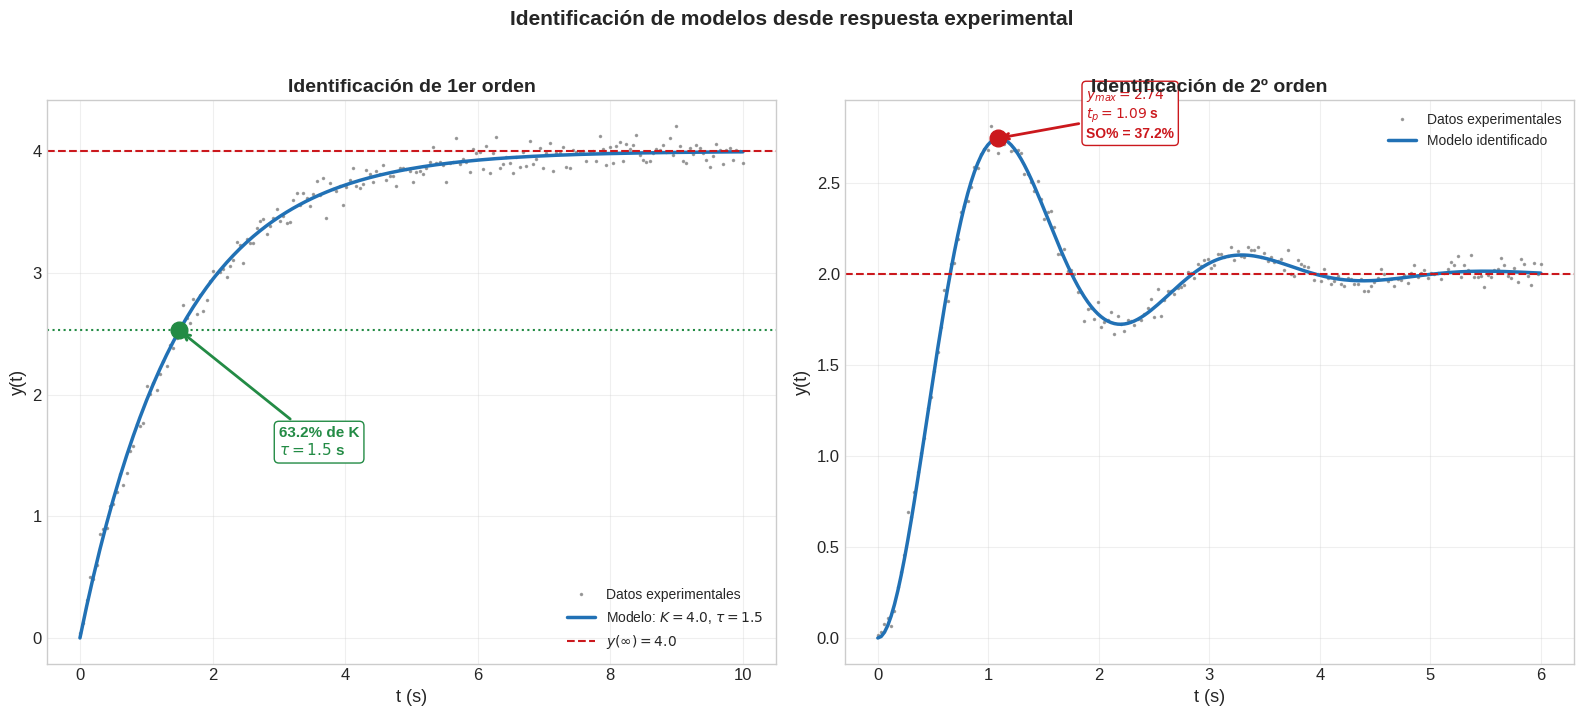

In [17]:
# PLOT 11: Identificación de primer y segundo orden desde curva experimental
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Primer orden ---
ax = axes[0]
tau_real = 1.5
K_real = 4.0
t = np.linspace(0, 10, 200)
y_real = K_real * (1 - np.exp(-t / tau_real))
# Añadir ruido simulado
np.random.seed(42)
y_exp = y_real + np.random.normal(0, 0.08, len(t))

ax.plot(t, y_exp, '.', color='gray', ms=3, alpha=0.7, label='Datos experimentales')
ax.plot(t, y_real, color=COLOR_PRINCIPAL, lw=2.5, label=rf'Modelo: $K={K_real}$, $\tau={tau_real}$')
ax.axhline(K_real, color=COLOR_RECTA, ls='--', lw=1.5, label=rf'$y(\infty) = {K_real}$')
ax.axhline(0.632 * K_real, color=COLOR_PUNTO, ls=':', lw=1.5)

# Marcar τ
ax.plot(tau_real, 0.632 * K_real, 'o', color=COLOR_PUNTO, ms=12, zorder=5)
ax.annotate(f'63.2% de K\n$\\tau = {tau_real}$ s',
            xy=(tau_real, 0.632 * K_real), xytext=(3, 1.5),
            fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Identificación de 1er orden', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Segundo orden ---
ax = axes[1]
wn_real = 3.0
zeta_real = 0.3
K_real2 = 2.0
sys_id = signal.TransferFunction([K_real2 * wn_real**2], [1, 2 * zeta_real * wn_real, wn_real**2])
t2 = np.linspace(0, 6, 200)
t2_out, y2_real = signal.step(sys_id, T=t2)
y2_exp = y2_real + np.random.normal(0, 0.04, len(t2))

ax.plot(t2, y2_exp, '.', color='gray', ms=3, alpha=0.7, label='Datos experimentales')
ax.plot(t2_out, y2_real, color=COLOR_PRINCIPAL, lw=2.5, label='Modelo identificado')
ax.axhline(K_real2, color=COLOR_RECTA, ls='--', lw=1.5)

# Marcar ymax y tp
y_max_id = np.max(y2_real)
t_peak_id = t2_out[np.argmax(y2_real)]
SO_id = (y_max_id - K_real2) / K_real2 * 100

ax.plot(t_peak_id, y_max_id, 'o', color=COLOR_RECTA, ms=12, zorder=5)
ax.annotate(f'$y_{{max}} = {y_max_id:.2f}$\n$t_p = {t_peak_id:.2f}$ s\nSO% = {SO_id:.1f}%',
            xy=(t_peak_id, y_max_id), xytext=(t_peak_id + 0.8, y_max_id),
            fontsize=10, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Identificación de 2º orden', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Identificación de modelos desde respuesta experimental',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Ejercicio resuelto: Identificación de 2º orden desde datos experimentales

**Datos leídos de la curva:** $y(\infty) = 5$, $y_{\max} = 6.5$, $t_p = 2$ s, escalón de amplitud $A = 1$.

**Paso 1:** Ganancia estática: $K = y(\infty)/A = 5/1 = 5$

**Paso 2:** Sobrepaso: $SO\% = \dfrac{6.5 - 5}{5} \times 100 = 30\%$

**Paso 3:** Factor de amortiguamiento:

$$\ln(0.30) = -1.204 \implies \zeta = \frac{1.204}{\sqrt{9.87 + 1.449}} = \frac{1.204}{3.364} = \boxed{0.358}$$

**Paso 4:** Frecuencia amortiguada: $\omega_d = \pi/t_p = \pi/2 = 1.571$ rad/s

**Paso 5:** Frecuencia natural: $\omega_n = \omega_d/\sqrt{1-\zeta^2} = 1.571/\sqrt{1-0.128} = 1.571/0.934 = \boxed{1.683\;\text{rad/s}}$

**Paso 6:** Modelo:

$$\boxed{G(s) = \frac{5 \times 2.832}{s^2 + 1.205s + 2.832} = \frac{14.16}{s^2 + 1.205s + 2.832}}$$

---

## 9. Efecto de los ceros en la respuesta temporal

Un **cero** en la función de transferencia modifica la forma de la respuesta sin cambiar los polos (ni la estabilidad). El efecto principal es:

- **Cero negativo** (semiplano izquierdo, $s = -z$, $z > 0$): **aumenta el sobrepaso** y acelera la respuesta
- **Cero positivo** (semiplano derecho, *non-minimum phase*): produce un **undershoot** inicial (la respuesta va primero en sentido contrario)
- Cuanto **más cerca del origen** está el cero, mayor es su efecto

La función de transferencia con un cero es:

$$G(s) = \frac{K\omega_n^2(1 + s/z)}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$

**Resumen visual: efecto de un cero sobre la respuesta**

| Ubicación del cero | Efecto sobre SO% | Efecto sobre $t_r$ | Ejemplo |
|--------------------|-------------------|---------------------|---------|
| $s = -z$ lejano ($z \gg \omega_n$) | Casi ninguno | Casi ninguno | $z = 100$ |
| $s = -z$ cercano ($z \approx \omega_n$) | **Aumenta** significativamente | **Disminuye** | $z = 1$ |
| $s = +z$ (semiplano derecho) | Puede disminuir | Puede aumentar + **undershoot** | $z = 2$ |

**Regla práctica:** Si $z > 10\omega_n$, el efecto del cero es despreciable.

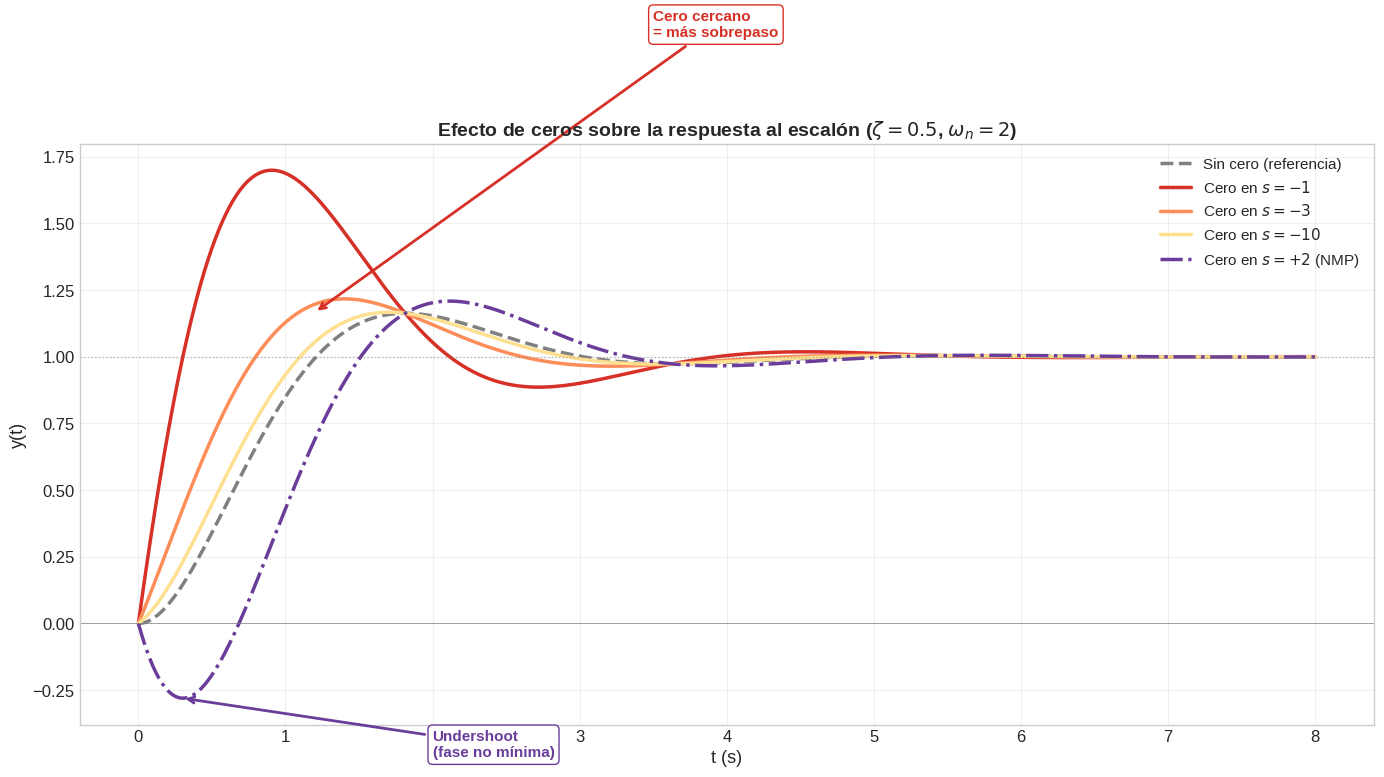

In [18]:
# PLOT 12: Efecto de ceros sobre la respuesta al escalón
fig, ax = plt.subplots(figsize=(14, 8))

wn = 2.0
zeta = 0.5
t = np.linspace(0, 8, 1000)

# Sin cero (referencia)
sys_ref = signal.TransferFunction([wn**2], [1, 2 * zeta * wn, wn**2])
t_out, y_ref = signal.step(sys_ref, T=t)
ax.plot(t_out, y_ref, color='gray', lw=2.5, ls='--', label='Sin cero (referencia)')

# Cero negativo cercano: z = 1
z_vals = [1, 3, 10]
colores_cero = ['#d73027', '#fc8d59', '#fee090']
for z, color in zip(z_vals, colores_cero):
    num = np.polymul([1.0 / z, 1], [wn**2])
    sys_z = signal.TransferFunction(num, [1, 2 * zeta * wn, wn**2])
    t_out, y_z = signal.step(sys_z, T=t)
    ax.plot(t_out, y_z, color=color, lw=2.5, label=rf'Cero en $s = -{z}$')

# Cero positivo (non-minimum phase): z = -2
num_nmp = np.polymul([-0.5, 1], [wn**2])  # (1 - s/2) → cero en s = +2
sys_nmp = signal.TransferFunction(num_nmp, [1, 2 * zeta * wn, wn**2])
t_out, y_nmp = signal.step(sys_nmp, T=t)
ax.plot(t_out, y_nmp, color=COLOR_PERM, lw=2.5, ls='-.', label=r'Cero en $s = +2$ (NMP)')

ax.axhline(1, color='gray', ls=':', lw=1, alpha=0.5)
ax.axhline(0, color='gray', lw=0.5)

ax.annotate('Undershoot\n(fase no mínima)', xy=(0.3, np.min(y_nmp)),
            xytext=(2, -0.5), fontsize=11, color=COLOR_PERM, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PERM, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PERM))

ax.annotate('Cero cercano\n= más sobrepaso', xy=(1.2, np.max(y_z)),
            xytext=(3.5, 2.2), fontsize=11, color='#d73027', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d73027', lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='#d73027'))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Efecto de ceros sobre la respuesta al escalón ($\zeta=0.5$, $\omega_n=2$)',
             fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 10. Respuesta a otras señales de prueba

### 10.1 Respuesta al impulso

La respuesta al impulso es la **derivada** de la respuesta al escalón. Para un sistema de primer orden:

$$\boxed{h(t) = \frac{K}{\tau} e^{-t/\tau}, \quad t \geq 0}$$

### 10.2 Respuesta a la rampa

Para un sistema de primer orden $G(s) = K/(\tau s + 1)$ ante rampa unitaria $R(s) = 1/s^2$:

$$\boxed{y(t) = K\left[t - \tau + \tau e^{-t/\tau}\right], \quad t \geq 0}$$

El **error en régimen permanente** ante rampa es $e_{ss} = K\tau$ (constante).

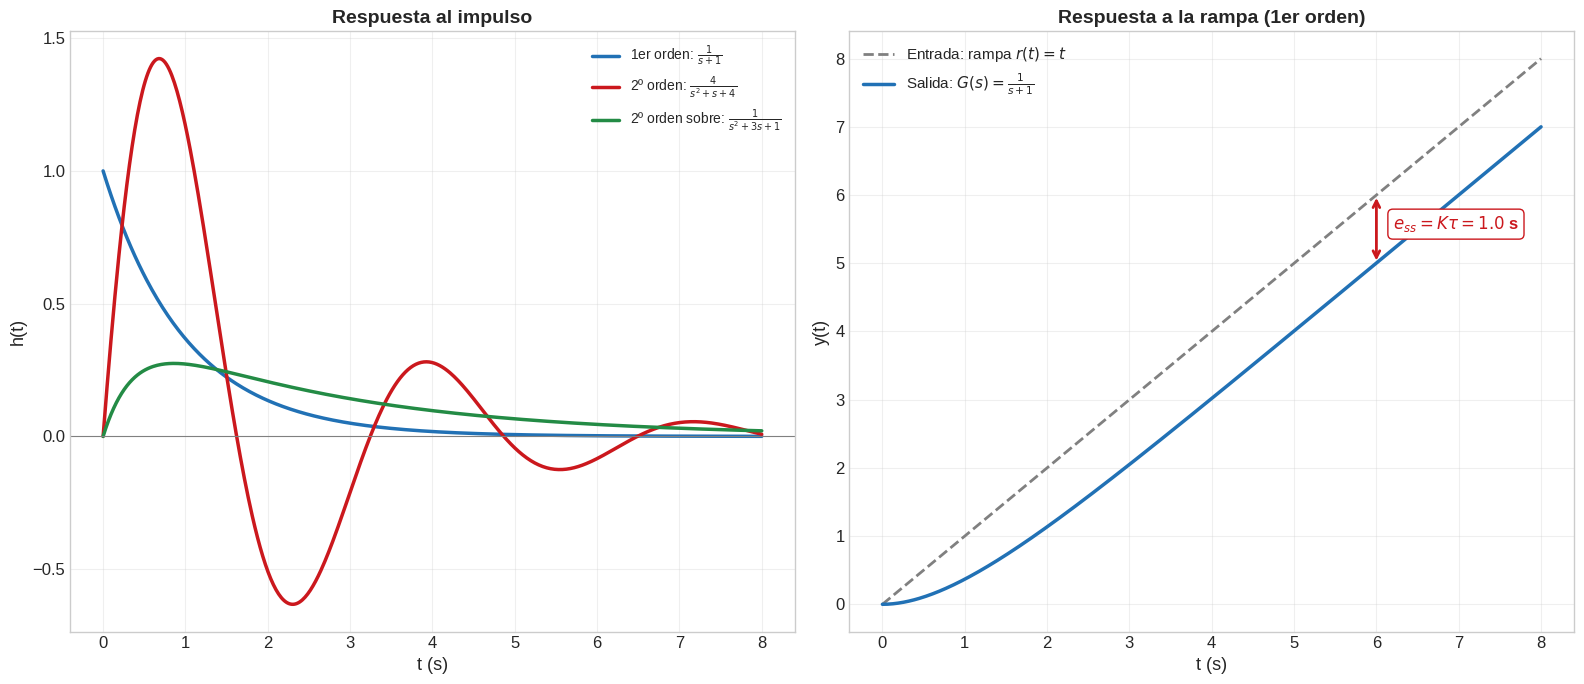

In [19]:
# PLOT 13: Respuesta al impulso y a la rampa de un sistema de 1er y 2º orden
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

t = np.linspace(0, 8, 500)

# --- Respuesta al impulso ---
ax = axes[0]

# Primer orden
sys_1 = signal.TransferFunction([1], [1, 1])  # K=1, τ=1
t_imp1, y_imp1 = signal.impulse(sys_1, T=t)
ax.plot(t_imp1, y_imp1, color=COLOR_PRINCIPAL, lw=2.5, label=r'1er orden: $\frac{1}{s+1}$')

# Segundo orden subamortiguado
sys_2 = signal.TransferFunction([4], [1, 1, 4])
t_imp2, y_imp2 = signal.impulse(sys_2, T=t)
ax.plot(t_imp2, y_imp2, color=COLOR_RECTA, lw=2.5, label=r'2º orden: $\frac{4}{s^2+s+4}$')

# Segundo orden sobreamortiguado
sys_3 = signal.TransferFunction([1], [1, 3, 1])
t_imp3, y_imp3 = signal.impulse(sys_3, T=t)
ax.plot(t_imp3, y_imp3, color=COLOR_PUNTO, lw=2.5, label=r'2º orden sobre: $\frac{1}{s^2+3s+1}$')

ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('t (s)')
ax.set_ylabel('h(t)')
ax.set_title('Respuesta al impulso', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Respuesta a la rampa (1er orden) ---
ax = axes[1]
tau = 1.0
K = 1.0
rampa = t
y_rampa = K * (t - tau + tau * np.exp(-t / tau))

ax.plot(t, rampa, color='gray', lw=2, ls='--', label='Entrada: rampa $r(t) = t$')
ax.plot(t, y_rampa, color=COLOR_PRINCIPAL, lw=2.5, label=r'Salida: $G(s) = \frac{1}{s+1}$')

# Error en régimen permanente
ax.annotate('', xy=(6, 6), xytext=(6, y_rampa[np.argmin(np.abs(t - 6))]),
            arrowprops=dict(arrowstyle='<->', color=COLOR_RECTA, lw=2))
ax.annotate(rf'$e_{{ss}} = K\tau = {K*tau}$ s', xy=(6.2, 5.5),
            fontsize=12, color=COLOR_RECTA, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Respuesta a la rampa (1er orden)', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Relación entre respuesta al impulso y al escalón:**

$$h(t) = \frac{d}{dt}[y_{\text{escalón}}(t)]$$

Esto es útil porque si se dispone de la respuesta al impulso, se puede obtener la respuesta al escalón por integración, y viceversa. En el dominio de Laplace, multiplicar por $1/s$ (escalón) equivale a integrar en el dominio temporal.

---

## 11. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica los **14 tipos** de problemas más frecuentes en exámenes de respuesta temporal.

| # | Tipo | Te dan | Te piden | Fórmula clave |
|---|------|--------|----------|---------------|
| 1 | Respuesta 1er orden al escalón | $G(s) = K/(\tau s+1)$ | $y(t)$, $y(\infty)$, $t_s$ | $y(t) = K(1-e^{-t/\tau})$ |
| 2 | Respuesta 2º orden al escalón | $G(s)$ estándar | $\zeta$, $\omega_n$, SO%, $t_s$, $t_r$ | Fórmulas de 2º orden |
| 3 | Calcular $\zeta$ y $\omega_n$ desde polos | Polos $s_{1,2}$ | $\zeta$, $\omega_n$ | $\omega_n = \|s\|$, $\zeta = \cos(\theta)$ |
| 4 | SO% desde $\zeta$ | $\zeta$ | SO% | $SO\% = e^{-\pi\zeta/\sqrt{1-\zeta^2}} \cdot 100$ |
| 5 | Calcular $t_s$ | $\zeta$, $\omega_n$ | $t_s$ | $t_s \approx 4/(\zeta\omega_n)$ |
| 6 | Tabla de Routh | Polinomio caract. | Estabilidad | Construcción de tabla |
| 7 | Rango de $K$ para estabilidad | Polinomio con $K$ | $K_{\min}$, $K_{\max}$ | Routh con $K$ simbólico |
| 8 | Polos dominantes | Sistema orden $> 2$ | Aproximación 2º orden | Regla $\times 5$ |
| 9 | Identificar modelo desde curva | Gráfica escalón | $K$, $\tau$ o $\zeta$, $\omega_n$ | Métodos de identificación |
| 10 | Efecto de ceros | $G(s)$ con cero | Cambio en SO% | Comparar con/sin cero |
| 11 | Respuesta a la rampa | $G(s)$ | $y(t)$, $e_{ss}$ | Respuesta rampa |
| 12 | Respuesta al impulso | $G(s)$ | $h(t)$ | $h(t) = \mathcal{L}^{-1}\{G(s)\}$ |
| 13 | Aproximación de orden superior | Sistema 3er/4º orden | Modelo reducido | Polos dominantes |
| 14 | Retardo temporal | $G(s) \cdot e^{-Ls}$ | Efecto del retardo | Padé: $e^{-Ls} \approx \frac{1-Ls/2}{1+Ls/2}$ |

---

### Metodología general de resolución

Para cualquier problema de respuesta temporal, seguir estos pasos:

1. **Identificar el tipo de sistema:** ¿1er orden, 2º orden, orden superior?
2. **Extraer parámetros:** $K$, $\tau$ (1er orden) o $K$, $\zeta$, $\omega_n$ (2º orden)
3. **Clasificar:** Si es 2º orden: ¿subamortiguado ($\zeta < 1$), críticamente amortiguado ($\zeta = 1$), o sobreamortiguado ($\zeta > 1$)?
4. **Aplicar fórmulas:** Usar las fórmulas correspondientes a la clasificación
5. **Verificar coherencia:** ¿El resultado tiene sentido físico? ¿Los tiempos son positivos? ¿El SO% está entre 0 y 100%?
6. **Si hay polos dominantes:** Simplificar a 2º orden antes de calcular

### 11.1 Tipo 1: Respuesta de primer orden al escalón

**Te dan:** $G(s) = \dfrac{K}{\tau s + 1}$ y entrada escalón de amplitud $A$.

**Te piden:** $y(t)$, $y(\infty)$, $t_s$, valor en un instante concreto.

$$\boxed{y(t) = K \cdot A \left(1 - e^{-t/\tau}\right)}$$

**Paso a paso:**
1. Identificar $K$ y $\tau$ comparando con la forma estándar
2. Calcular $y(\infty) = K \cdot A$
3. Para valor en $t_0$: sustituir en la fórmula
4. $t_s(2\%) = 4\tau$, $t_s(5\%) = 3\tau$

#### Ejercicio: $G(s) = \dfrac{5}{0.5s+1}$, escalón de amplitud 2

**Datos:** $K = 5$, $\tau = 0.5$ s, $A = 2$

$$y(t) = 5 \times 2 \times (1 - e^{-t/0.5}) = 10(1 - e^{-2t})$$

$$y(\infty) = 10, \qquad t_s(2\%) = 4 \times 0.5 = \boxed{2\;\text{s}}$$

$$y(0.5) = 10(1 - e^{-1}) = 10 \times 0.632 = 6.32$$

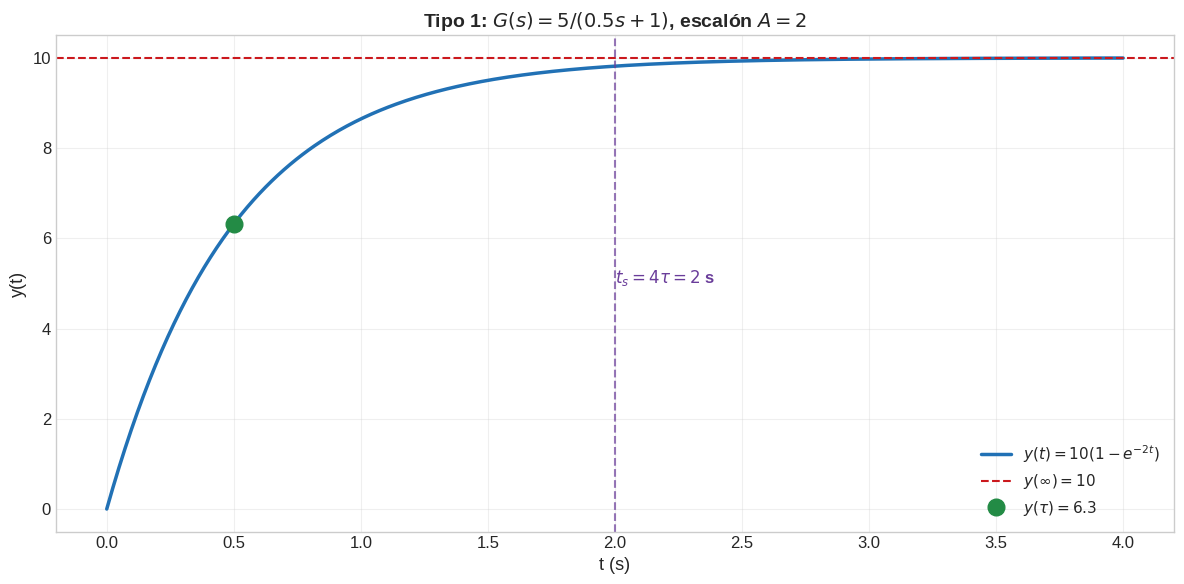

In [20]:
# PLOT adicional: Verificación tipo 1 - G(s) = 5/(0.5s+1), escalón A=2
fig, ax = plt.subplots(figsize=(12, 6))

sys_t1 = signal.TransferFunction([5 * 2], [0.5, 1])  # K*A = 10
t = np.linspace(0, 4, 500)
t_out, y_out = signal.step(sys_t1, T=t)
# Nota: scipy step aplica escalón unitario, pero hemos puesto K*A en numerador

# En realidad hay que hacer la respuesta manual: y(t) = 10(1-exp(-2t))
y_manual = 10 * (1 - np.exp(-2 * t))
ax.plot(t, y_manual, color=COLOR_PRINCIPAL, lw=2.5, label=r'$y(t) = 10(1-e^{-2t})$')
ax.axhline(10, color=COLOR_RECTA, ls='--', lw=1.5, label=r'$y(\infty) = 10$')
ax.plot(0.5, 10 * 0.632, 'o', color=COLOR_PUNTO, ms=12, zorder=5,
        label=rf'$y(\tau) = {10*0.632:.1f}$')

# ts = 4τ = 2s
ax.axvline(2.0, color=COLOR_PERM, ls='--', lw=1.5, alpha=0.7)
ax.annotate(r'$t_s = 4\tau = 2$ s', xy=(2.0, 5), fontsize=12, color=COLOR_PERM, fontweight='bold')

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Tipo 1: $G(s) = 5/(0.5s+1)$, escalón $A=2$', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.2 Tipo 2: Respuesta de segundo orden al escalón

**Te dan:** $G(s)$ en forma estándar o expandida.

**Te piden:** $\zeta$, $\omega_n$, SO%, $t_s$, $t_r$, $t_p$, $\omega_d$, polos.

**Paso a paso:**
1. Poner en forma estándar: $\dfrac{K\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$
2. Identificar $\omega_n^2$ del término independiente del denominador
3. Identificar $2\zeta\omega_n$ del coeficiente de $s$
4. Clasificar según $\zeta$ (sub/sobre/crítico)
5. Aplicar fórmulas correspondientes

#### Ejercicio: $G(s) = \dfrac{25}{s^2 + 6s + 25}$

**Paso 1:** $\omega_n^2 = 25 \implies \omega_n = 5$ rad/s

**Paso 2:** $2\zeta\omega_n = 6 \implies \zeta = 6/(2 \times 5) = 0.6$ (subamortiguado)

**Paso 3:** $\omega_d = 5\sqrt{1 - 0.36} = 5 \times 0.8 = 4$ rad/s

**Paso 4:** $SO\% = e^{-\pi \times 0.6/0.8} \times 100 = e^{-2.356} \times 100 = \boxed{9.48\%}$

**Paso 5:** $t_s \approx 4/(0.6 \times 5) = \boxed{1.33\;\text{s}}$

**Paso 6:** $t_r \approx (\pi - \arccos(0.6))/4 = (3.1416 - 0.9273)/4 = \boxed{0.554\;\text{s}}$

**Paso 7:** $t_p = \pi/4 = \boxed{0.785\;\text{s}}$

**Paso 8:** Polos: $s_{1,2} = -3 \pm 4j$

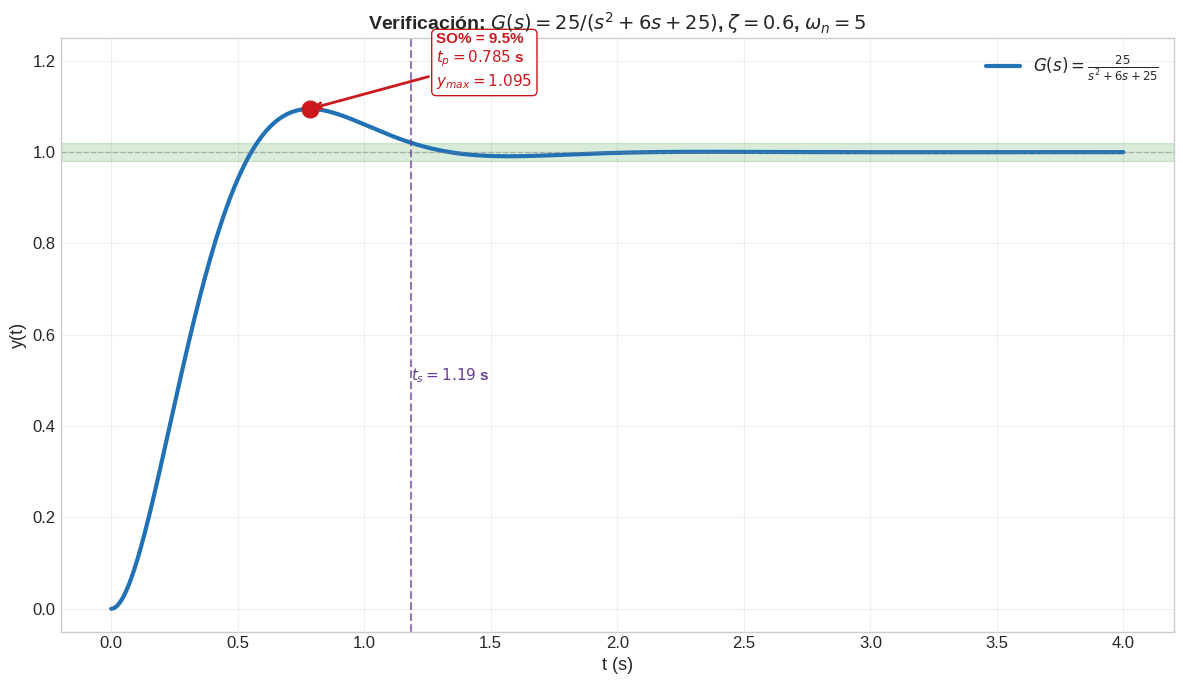

In [21]:
# PLOT adicional: Verificación del ejemplo resuelto tipo 2 con scipy
fig, ax = plt.subplots(figsize=(12, 7))

# G(s) = 25/(s²+6s+25) → ωn=5, ζ=0.6
sys_ej = signal.TransferFunction([25], [1, 6, 25])
t = np.linspace(0, 4, 1000)
t_out, y_out = signal.step(sys_ej, T=t)

ax.plot(t_out, y_out, color=COLOR_PRINCIPAL, lw=3, label=r'$G(s) = \frac{25}{s^2+6s+25}$')
ax.axhline(1, color='gray', ls='--', lw=1, alpha=0.5)

# Marcar SO%
y_max = np.max(y_out)
t_peak = t_out[np.argmax(y_out)]
SO = (y_max - 1) * 100
ax.plot(t_peak, y_max, 'o', color=COLOR_RECTA, ms=12, zorder=5)
ax.annotate(f'SO% = {SO:.1f}%\n$t_p = {t_peak:.3f}$ s\n$y_{{max}} = {y_max:.3f}$',
            xy=(t_peak, y_max), xytext=(t_peak + 0.5, y_max + 0.05),
            fontsize=11, color=COLOR_RECTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_RECTA, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_RECTA))

# Banda ±2%
ax.axhspan(0.98, 1.02, alpha=0.15, color='green')

# ts
band = 0.02
idx_s = np.where(np.abs(y_out - 1) > band)[0]
ts_val = t_out[idx_s[-1]] if len(idx_s) > 0 else t_out[-1]
ax.axvline(ts_val, color=COLOR_PERM, ls='--', lw=1.5, alpha=0.7)
ax.annotate(f'$t_s = {ts_val:.2f}$ s', xy=(ts_val, 0.5),
            fontsize=11, color=COLOR_PERM, fontweight='bold')

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title(r'Verificación: $G(s) = 25/(s^2+6s+25)$, $\zeta=0.6$, $\omega_n=5$', fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.25)
plt.tight_layout()
plt.show()

### 11.3 Tipo 3: Calcular $\zeta$ y $\omega_n$ desde los polos

**Te dan:** Polos $s_{1,2} = -\sigma \pm j\omega_d$

**Te piden:** $\zeta$, $\omega_n$

$$\boxed{\omega_n = \sqrt{\sigma^2 + \omega_d^2} = |s|} \qquad \boxed{\zeta = \frac{\sigma}{\omega_n} = \cos(\theta)}$$

donde $\theta = \arctan(\omega_d / \sigma)$ es el ángulo respecto al eje real negativo.

#### Ejercicio: Polos en $s_{1,2} = -2 \pm 3j$

$$\omega_n = \sqrt{2^2 + 3^2} = \sqrt{4 + 9} = \sqrt{13} = \boxed{3.606\;\text{rad/s}}$$

$$\zeta = \frac{2}{3.606} = \boxed{0.555}$$

### 11.4 Tipo 4: SO% desde $\zeta$ (y viceversa)

**Directo:** dado $\zeta$, calcular SO%:

$$SO\% = e^{-\pi\zeta / \sqrt{1-\zeta^2}} \cdot 100$$

**Inverso:** dado SO%, calcular $\zeta$:

$$\boxed{\zeta = \frac{-\ln(SO/100)}{\sqrt{\pi^2 + \ln^2(SO/100)}}}$$

#### Ejercicio: Dado SO% = 20%, hallar $\zeta$

$$\ln(0.20) = -1.6094$$

$$\zeta = \frac{1.6094}{\sqrt{\pi^2 + 1.6094^2}} = \frac{1.6094}{\sqrt{9.8696 + 2.5902}} = \frac{1.6094}{3.533} = \boxed{0.456}$$

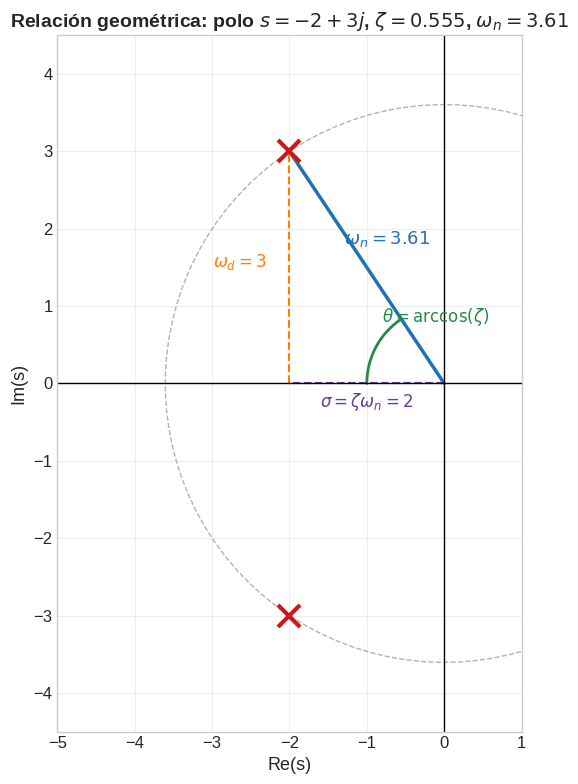

In [22]:
# PLOT adicional: Relación geométrica ζ-θ-ωn en el plano s (tipo 3)
fig, ax = plt.subplots(figsize=(8, 8))

# Polo de ejemplo: s = -2+3j
sigma, wd = 2, 3
wn = np.sqrt(sigma**2 + wd**2)
zeta_val = sigma / wn

ax.plot(-sigma, wd, 'x', color=COLOR_RECTA, ms=16, mew=3, zorder=5)
ax.plot(-sigma, -wd, 'x', color=COLOR_RECTA, ms=16, mew=3, zorder=5)

# Radio ωn
theta_c = np.linspace(0, 2 * np.pi, 100)
ax.plot(wn * np.cos(theta_c), wn * np.sin(theta_c), 'k--', lw=1, alpha=0.3)

# Línea desde origen
ax.plot([0, -sigma], [0, wd], color=COLOR_PRINCIPAL, lw=2.5)
ax.annotate(rf'$\omega_n = {wn:.2f}$', xy=(-sigma/2 - 0.3, wd/2 + 0.3),
            fontsize=13, color=COLOR_PRINCIPAL, fontweight='bold')

# Ángulo
angle_arc = np.linspace(np.pi, np.pi - np.arctan2(wd, sigma), 50)
r_arc = 1.0
ax.plot(r_arc * np.cos(angle_arc), r_arc * np.sin(angle_arc), color=COLOR_PUNTO, lw=2)
ax.annotate(rf'$\theta = \arccos(\zeta)$', xy=(-0.8, 0.8),
            fontsize=12, color=COLOR_PUNTO, fontweight='bold')

# Componentes
ax.plot([-sigma, -sigma], [0, wd], '--', color=COLOR_TRANS, lw=1.5)
ax.annotate(rf'$\omega_d = {wd}$', xy=(-sigma - 0.3, wd/2),
            fontsize=12, color=COLOR_TRANS, fontweight='bold', ha='right')

ax.plot([0, -sigma], [0, 0], '--', color=COLOR_PERM, lw=1.5)
ax.annotate(rf'$\sigma = \zeta\omega_n = {sigma}$', xy=(-sigma/2, -0.3),
            fontsize=12, color=COLOR_PERM, fontweight='bold', ha='center')

ax.axhline(0, color='k', lw=1)
ax.axvline(0, color='k', lw=1)

ax.set_xlabel(r'Re(s)')
ax.set_ylabel(r'Im(s)')
ax.set_title(rf'Relación geométrica: polo $s = -{sigma}+{wd}j$, $\zeta = {zeta_val:.3f}$, $\omega_n = {wn:.2f}$',
             fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(-5, 1)
ax.set_ylim(-4.5, 4.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.5 Tipo 5: Cálculo de $t_s$

**Te dan:** $\zeta$, $\omega_n$ (o datos para calcularlos)

**Te piden:** Tiempo de establecimiento

$$\boxed{t_s(2\%) \approx \frac{4}{\zeta\omega_n}} \qquad \boxed{t_s(5\%) \approx \frac{3}{\zeta\omega_n}}$$

#### Ejercicio: $\zeta = 0.5$, $\omega_n = 4$ rad/s

$$t_s(2\%) = \frac{4}{0.5 \times 4} = \frac{4}{2} = \boxed{2\;\text{s}}$$

### 11.6 Tipo 6: Tabla de Routh (estabilidad directa)

**Te dan:** Polinomio característico con coeficientes numéricos.

**Te piden:** ¿Es estable? ¿Cuántos polos inestables?

**Paso a paso:**
1. Verificar condición necesaria (todos coeficientes mismo signo y no nulos)
2. Construir tabla de Routh fila por fila
3. Contar cambios de signo en primera columna
4. Cambios de signo = número de polos con $Re > 0$

#### Ejercicio: $s^4 + 2s^3 + 3s^2 + 4s + 5 = 0$

| Fila | Col 1 | Col 2 | Col 3 |
|------|-------|-------|-------|
| $s^4$ | $1$ | $3$ | $5$ |
| $s^3$ | $2$ | $4$ | $0$ |
| $s^2$ | $\frac{2 \times 3 - 1 \times 4}{2} = 1$ | $\frac{2 \times 5 - 1 \times 0}{2} = 5$ | |
| $s^1$ | $\frac{1 \times 4 - 2 \times 5}{1} = -6$ | | |
| $s^0$ | $5$ | | |

Primera columna: $\{1, 2, 1, -6, 5\}$ $\to$ **2 cambios de signo** ($1 \to -6$ y $-6 \to 5$).

$$\boxed{\text{INESTABLE: 2 polos en semiplano derecho}}$$

---

**Errores frecuentes en el criterio de Routh-Hurwitz:**

1. **Olvidar la condición necesaria:** Si algún coeficiente es negativo o cero, el sistema ya es inestable (para polinomios con coeficientes reales positivos).
2. **Confundir cambios de signo:** $\{+, -, +\}$ tiene **2 cambios** de signo $\to$ 2 polos inestables.
3. **No normalizar:** El coeficiente líder ($a_n$) debe ser positivo. Si es negativo, multiplicar todo por $-1$.
4. **Fila de ceros:** Indica polos simétricos (ej. $\pm j\omega$), requiere tratamiento especial con polinomio auxiliar.

### 11.7 Tipo 7: Rango de $K$ para estabilidad

**Te dan:** Polinomio característico con parámetro $K$.

**Te piden:** Rango de $K$ que garantiza estabilidad.

**Paso a paso:**
1. Construir tabla de Routh dejando $K$ como variable
2. Imponer que todos los elementos de la primera columna sean positivos
3. Resolver las desigualdades

#### Ejercicio: $s^4 + 4s^3 + 6s^2 + 4s + K = 0$

| Fila | Col 1 | Col 2 | Col 3 |
|------|-------|-------|-------|
| $s^4$ | $1$ | $6$ | $K$ |
| $s^3$ | $4$ | $4$ | |
| $s^2$ | $\frac{4 \times 6 - 1 \times 4}{4} = 5$ | $K$ | |
| $s^1$ | $\frac{5 \times 4 - 4K}{5} = \frac{20 - 4K}{5}$ | | |
| $s^0$ | $K$ | | |

Condiciones: $K > 0$ y $\dfrac{20 - 4K}{5} > 0 \implies K < 5$

$$\boxed{0 < K < 5}$$

### 11.8 Tipo 8: Polos dominantes

**Te dan:** Sistema de orden $\geq 3$ con polos calculados.

**Te piden:** Modelo aproximado de 2º orden.

**Paso a paso:**
1. Calcular todos los polos
2. Identificar los polos más cercanos al eje imaginario (menor $|\text{Re}|$)
3. Verificar que la regla $\times 5$ se cumple
4. Construir modelo de 2º orden con los polos dominantes

#### Ejercicio: $G(s) = \dfrac{60}{(s^2 + 2s + 5)(s + 6)}$

Polos: $s_{1,2} = -1 \pm 2j$ (dominantes), $s_3 = -6$ (lejano).

Verificación: $|{-6}| / |{-1}| = 6 > 5$ $\to$ se puede aproximar.

Modelo reducido con ganancia estática unitaria:

$$G_{\text{aprox}}(s) = \frac{5}{s^2 + 2s + 5}$$

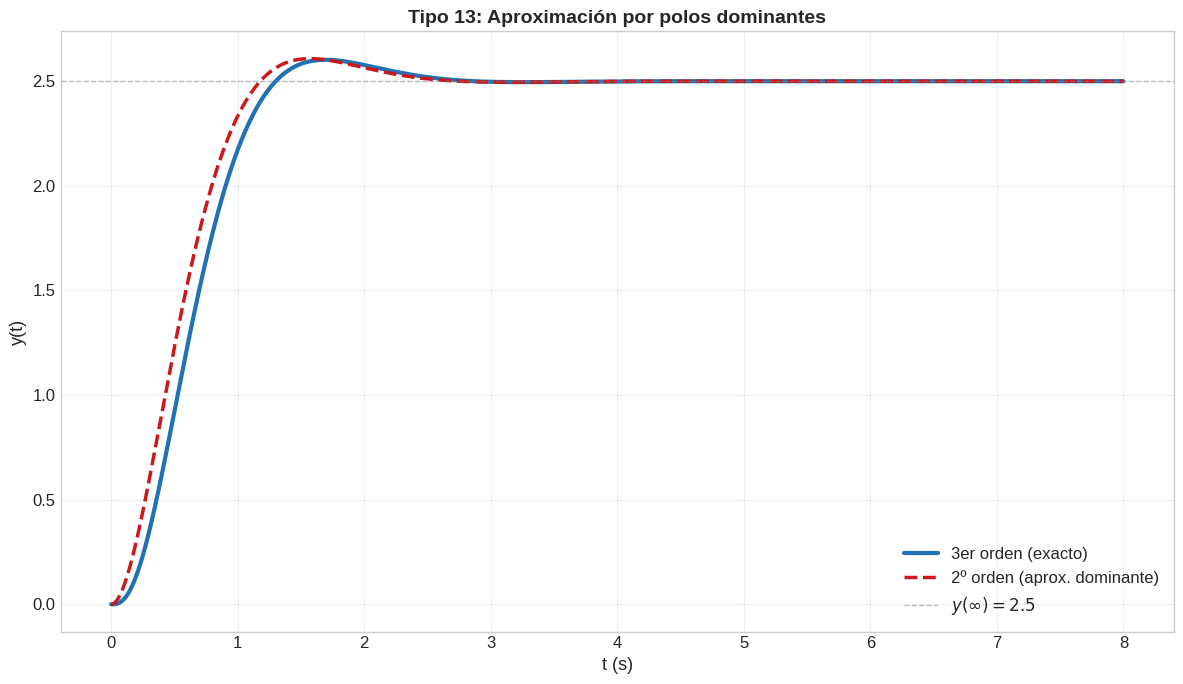

In [23]:
# PLOT adicional: Comparación 3er orden vs aproximación de 2º orden (tipo 13)
fig, ax = plt.subplots(figsize=(12, 7))

t = np.linspace(0, 8, 1000)

# G(s) = 200/[(s+10)(s²+4s+8)]
num_3 = [200]
den_3 = np.polymul([1, 10], [1, 4, 8])
# Ganancia estática
K_3 = 200 / (10 * 8)  # = 2.5

sys_3o = signal.TransferFunction(num_3, den_3)
t3, y3 = signal.step(sys_3o, T=t)

# Aproximación: G_aprox(s) = 20/(s²+4s+8)
sys_aprox = signal.TransferFunction([20], [1, 4, 8])
ta, ya = signal.step(sys_aprox, T=t)

ax.plot(t3, y3, color=COLOR_PRINCIPAL, lw=3, label='3er orden (exacto)')
ax.plot(ta, ya, '--', color=COLOR_RECTA, lw=2.5, label=r'2º orden (aprox. dominante)')
ax.axhline(K_3, color='gray', ls='--', lw=1, alpha=0.5, label=rf'$y(\infty) = {K_3}$')

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Tipo 13: Aproximación por polos dominantes', fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.9 Tipo 9: Identificar modelo desde curva experimental

**Te dan:** Gráfica de respuesta al escalón (con valores numéricos legibles).

**Te piden:** Función de transferencia $G(s)$.

**Para primer orden (sin oscilaciones, sin sobrepaso):**
1. $K = y(\infty) / A$
2. $\tau$: leer el tiempo donde $y = 0.632 \cdot y(\infty)$
3. $G(s) = K/(\tau s + 1)$

**Para segundo orden (con oscilaciones):**
1. $K = y(\infty) / A$
2. $SO\% = (y_{\max} - y(\infty)) / y(\infty) \times 100$
3. $\zeta = -\ln(SO/100) / \sqrt{\pi^2 + \ln^2(SO/100)}$
4. $t_p$ = tiempo del primer pico
5. $\omega_d = \pi / t_p$
6. $\omega_n = \omega_d / \sqrt{1 - \zeta^2}$
7. $G(s) = K\omega_n^2 / (s^2 + 2\zeta\omega_n s + \omega_n^2)$

#### Ejercicio: De la curva se lee $y(\infty) = 3$, $y_{\max} = 3.9$, $t_p = 1.5$ s, escalón de amplitud 1

$$K = 3, \quad SO\% = \frac{3.9 - 3}{3} \times 100 = 30\%$$

$$\zeta = \frac{-\ln(0.30)}{\sqrt{\pi^2 + \ln^2(0.30)}} = \frac{1.204}{\sqrt{9.87 + 1.45}} = \frac{1.204}{3.364} = \boxed{0.358}$$

$$\omega_d = \frac{\pi}{1.5} = 2.094\;\text{rad/s}$$

$$\omega_n = \frac{2.094}{\sqrt{1 - 0.128}} = \frac{2.094}{0.934} = \boxed{2.243\;\text{rad/s}}$$

$$\boxed{G(s) = \frac{3 \times 5.03}{s^2 + 1.607s + 5.03} = \frac{15.09}{s^2 + 1.607s + 5.03}}$$

### 11.10 Tipo 10: Efecto de ceros

**Te dan:** $G(s)$ con cero adicional.

**Te piden:** Comparar respuesta con y sin cero, explicar efecto.

**Reglas clave:**
- Cero en $s = -z$ (semiplano izquierdo): **aumenta** SO% y **acelera** la respuesta
- Cuanto menor es $z$ (cero más cerca del origen), mayor es el efecto
- Cero en $s = +z$ (semiplano derecho): produce **undershoot** (*non-minimum phase*)

### 11.11 Tipo 11: Respuesta a la rampa

**Te dan:** $G(s)$ y entrada rampa.

**Te piden:** $y(t)$, error en régimen permanente.

Para primer orden $G(s) = K/(\tau s + 1)$:

$$y(t) = K[t - \tau + \tau e^{-t/\tau}] \qquad e_{ss} = K\tau$$

#### Ejercicio: $G(s) = \dfrac{2}{3s+1}$, rampa unitaria

$$e_{ss} = K\tau = 2 \times 3 = \boxed{6}$$

### 11.12 Tipo 12: Respuesta al impulso

**Te dan:** $G(s)$ y entrada impulso $\delta(t)$.

**Te piden:** $h(t)$ = respuesta impulsional.

$$h(t) = \mathcal{L}^{-1}\{G(s)\}$$

Para primer orden: $h(t) = \dfrac{K}{\tau} e^{-t/\tau}$

Para segundo orden subamortiguado: $h(t) = \dfrac{K\omega_n^2}{\omega_d} e^{-\zeta\omega_n t} \sin(\omega_d t)$

#### Ejercicio: $G(s) = \dfrac{4}{2s+1}$

$$h(t) = \frac{4}{2} e^{-t/2} = \boxed{2 e^{-0.5t}}$$

---

**Tabla de fórmulas inversas útiles para identificación:**

| Dato experimental | Fórmula para obtener parámetro | Parámetro |
|-------------------|--------------------------------|-----------|
| $y(\infty)$ y amplitud $A$ | $K = y(\infty)/A$ | Ganancia estática |
| Tiempo al 63.2% | $\tau = t_{63.2\%}$ | Constante de tiempo |
| $y_{\max}$ y $y(\infty)$ | $SO\% = (y_{\max} - y(\infty))/y(\infty) \times 100$ | Sobrepaso |
| SO% | $\zeta = \|\ln(SO/100)\| / \sqrt{\pi^2 + \ln^2(SO/100)}$ | Amortiguamiento |
| $t_p$ | $\omega_d = \pi / t_p$ | Frec. amortiguada |
| $\omega_d$ y $\zeta$ | $\omega_n = \omega_d / \sqrt{1-\zeta^2}$ | Frec. natural |
| Periodo de oscilación $T$ | $\omega_d = 2\pi / T$ | Frec. amortiguada |

### 11.13 Tipo 13: Aproximación de sistema de orden superior

**Te dan:** Sistema de 3er o 4º orden.

**Te piden:** Modelo reducido de 2º orden y comparación de respuestas.

**Paso a paso:**
1. Factorizar denominador y encontrar todos los polos
2. Identificar par de polos complejos conjugados más cercanos al eje imaginario
3. Verificar que los polos restantes son al menos $5\times$ más lejanos
4. Construir $G_{\text{aprox}}(s)$ con los polos dominantes, ajustando $K$ para mantener la ganancia estática

#### Ejercicio: $G(s) = \dfrac{200}{(s+10)(s^2 + 4s + 8)}$

Polos: $s_1 = -10$, $s_{2,3} = -2 \pm 2j$ (dominantes)

Verificación: $10 / 2 = 5$ $\to$ justo en el límite, pero aceptable.

Ganancia estática original: $G(0) = 200 / (10 \times 8) = 2.5$

$$\boxed{G_{\text{aprox}}(s) = \frac{2.5 \times 8}{s^2 + 4s + 8} = \frac{20}{s^2 + 4s + 8}}$$

### 11.14 Tipo 14: Aproximación de retardo temporal (Padé)

**Te dan:** $G(s) \cdot e^{-Ls}$ donde $L$ es el retardo puro.

**Te piden:** Aproximación racional del retardo.

La **aproximación de Padé de primer orden** convierte el retardo en una función racional:

$$\boxed{e^{-Ls} \approx \frac{1 - Ls/2}{1 + Ls/2} = \frac{2 - Ls}{2 + Ls}}$$

**Error frecuente:** El cero está en el semiplano **derecho** ($s = 2/L > 0$), lo que introduce un **undershoot** en la respuesta. El retardo NO afecta a la estabilidad del sistema en lazo abierto, pero sí reduce los márgenes de estabilidad en lazo cerrado.

#### Ejercicio: $G(s) = \dfrac{5}{2s+1} \cdot e^{-0.5s}$

Aproximación Padé: $e^{-0.5s} \approx \dfrac{1 - 0.25s}{1 + 0.25s}$

$$G_{\text{aprox}}(s) = \frac{5}{2s+1} \cdot \frac{1 - 0.25s}{1 + 0.25s} = \frac{5(1 - 0.25s)}{(2s+1)(0.25s+1)}$$

---

### Tabla resumen del catálogo por tipo

| # | Tipo | Lo más importante |
|---|------|-------------------|
| 1 | Resp. 1er orden escalón | $y(t) = KA(1-e^{-t/\tau})$, $t_s = 4\tau$ |
| 2 | Resp. 2º orden escalón | Identificar $\zeta$, $\omega_n$, luego fórmulas |
| 3 | $\zeta$, $\omega_n$ desde polos | $\omega_n = \|s\|$, $\zeta = \cos\theta$ |
| 4 | SO% $\leftrightarrow$ $\zeta$ | Fórmula exponencial (directa e inversa) |
| 5 | $t_s$ | $4/(\zeta\omega_n)$ al 2%, $3/(\zeta\omega_n)$ al 5% |
| 6 | Routh (numérico) | Construir tabla, contar cambios de signo |
| 7 | Routh (paramétrico) | Dejar $K$ simbólico, resolver desigualdades |
| 8 | Polos dominantes | Regla $\times 5$, ajustar ganancia estática |
| 9 | Identificar desde curva | Leer $y(\infty)$, $y_{\max}$, $t_p$ o $t_{63\%}$ |
| 10 | Efecto de ceros | Cero cercano $\to$ más SO%, cero RHP $\to$ undershoot |
| 11 | Resp. rampa | $e_{ss} = K\tau$ (1er orden) |
| 12 | Resp. impulso | $h(t) = \mathcal{L}^{-1}\{G(s)\}$ |
| 13 | Aprox. orden superior | Factorizar, identificar dominantes, reducir |
| 14 | Retardo (Padé) | $(2-Ls)/(2+Ls)$, cuidado con undershoot |

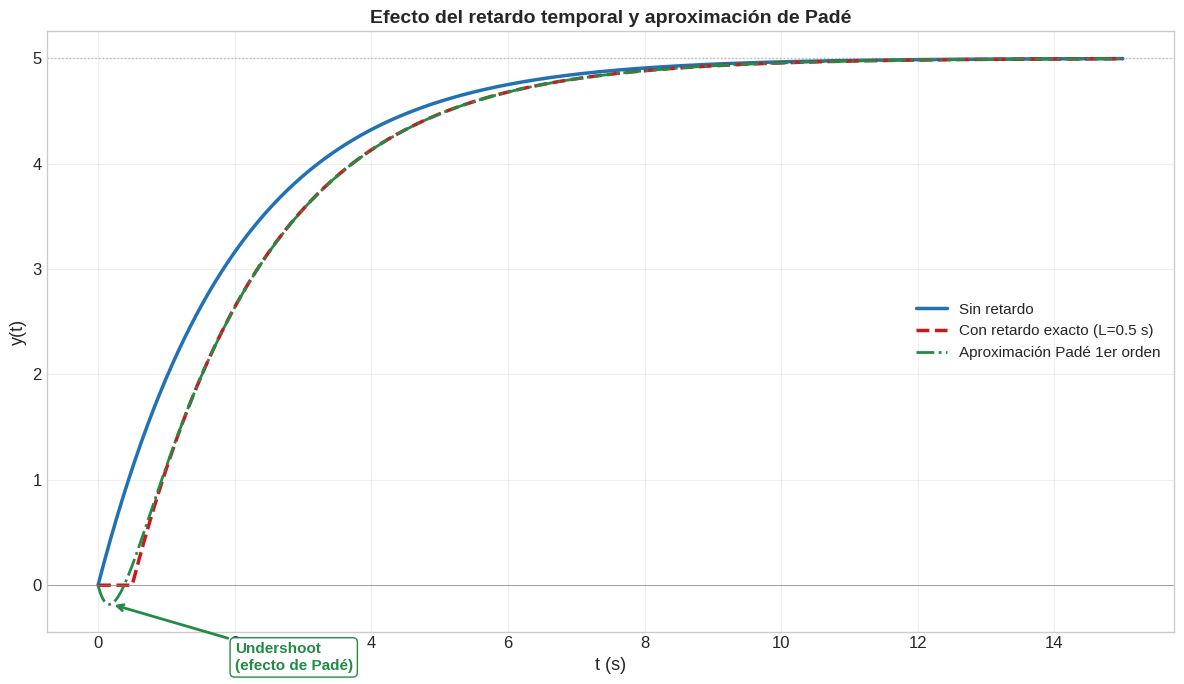

In [24]:
# PLOT 14: Efecto del retardo temporal con aproximación de Padé
fig, ax = plt.subplots(figsize=(12, 7))

t = np.linspace(0, 15, 1000)

# Sistema sin retardo: G(s) = 5/(2s+1)
sys_sin = signal.TransferFunction([5], [2, 1])
t_s, y_sin = signal.step(sys_sin, T=t)

# Sistema con retardo L=0.5s (exacto: desplazar la curva)
L = 0.5
y_retardo_exacto = np.where(t >= L, 5 * (1 - np.exp(-(t - L) / 2)), 0)

# Aproximación Padé: 5(1-0.25s) / [(2s+1)(0.25s+1)]
num_pade = np.polymul([5], [-0.25, 1])         # 5*(1-0.25s)
den_pade = np.polymul([2, 1], [0.25, 1])       # (2s+1)(0.25s+1)
sys_pade = signal.TransferFunction(num_pade, den_pade)
t_p, y_pade = signal.step(sys_pade, T=t)

ax.plot(t_s, y_sin, color=COLOR_PRINCIPAL, lw=2.5, label='Sin retardo')
ax.plot(t, y_retardo_exacto, color=COLOR_RECTA, lw=2.5, ls='--', label=f'Con retardo exacto (L={L} s)')
ax.plot(t_p, y_pade, color=COLOR_PUNTO, lw=2, ls='-.', label=r'Aproximación Padé 1er orden')

ax.axhline(5, color='gray', ls=':', lw=1, alpha=0.5)
ax.axhline(0, color='gray', lw=0.5)

ax.annotate('Undershoot\n(efecto de Padé)', xy=(0.2, np.min(y_pade)),
            xytext=(2, -0.8), fontsize=11, color=COLOR_PUNTO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2),
            bbox=dict(boxstyle='round', facecolor='white', edgecolor=COLOR_PUNTO))

ax.set_xlabel('t (s)')
ax.set_ylabel('y(t)')
ax.set_title('Efecto del retardo temporal y aproximación de Padé', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 12. Resumen y tablas de fórmulas clave

### 12.1 Primer orden: $G(s) = K/(\tau s + 1)$

| Fórmula | Uso |
|---------|-----|
| $y(t) = K(1-e^{-t/\tau})$ | Respuesta al escalón unitario |
| $h(t) = (K/\tau)e^{-t/\tau}$ | Respuesta al impulso |
| $t_s(2\%) = 4\tau$ | Tiempo de establecimiento |
| $t_s(5\%) = 3\tau$ | Tiempo de establecimiento (criterio 5%) |
| $y(\tau) = 0.632K$ | Valor a una constante de tiempo |
| Polo: $s = -1/\tau$ | Ubicación en plano $s$ |

### 12.2 Segundo orden: $G(s) = K\omega_n^2/(s^2 + 2\zeta\omega_n s + \omega_n^2)$

| Fórmula | Uso |
|---------|-----|
| $SO\% = e^{-\pi\zeta/\sqrt{1-\zeta^2}} \cdot 100$ | Sobrepaso máximo |
| $\zeta = -\ln(SO/100)/\sqrt{\pi^2 + \ln^2(SO/100)}$ | $\zeta$ desde SO% (inversa) |
| $t_s(2\%) \approx 4/(\zeta\omega_n)$ | Tiempo de establecimiento |
| $t_p = \pi/\omega_d$ | Tiempo de pico |
| $t_r \approx (\pi - \arccos\zeta)/\omega_d$ | Tiempo de subida |
| $\omega_d = \omega_n\sqrt{1-\zeta^2}$ | Frecuencia amortiguada |
| $s_{1,2} = -\zeta\omega_n \pm j\omega_d$ | Polos |
| $\omega_n = \sqrt{\sigma^2 + \omega_d^2}$ | $\omega_n$ desde polos |
| $\zeta = \sigma/\omega_n = \cos(\theta)$ | $\zeta$ desde polos |

### 12.3 Estabilidad

| Concepto | Condición |
|----------|-----------|
| **Estable** | Todos los polos con $Re < 0$ |
| **Routh-Hurwitz** | Primera columna toda positiva (o toda negativa) |
| **Cambios de signo** | = Número de polos inestables |
| **Polos dominantes** | $\|Re(p_{\text{lejano}})\| \geq 5 \cdot \|Re(p_{\text{dom}})\|$ |

### 12.4 Identificación

| Dato medido | Fórmula | Parámetro obtenido |
|-------------|---------|-------------------|
| $y(\infty)$ | $K = y(\infty)/A$ | Ganancia estática |
| $y(t_{63\%})$ | $\tau = t_{63\%}$ | Constante de tiempo (1er orden) |
| $y_{\max}$ | $SO\% \to \zeta$ | Factor de amortiguamiento |
| $t_p$ | $\omega_d = \pi/t_p$ | Frecuencia amortiguada |

### 12.5 Retardo temporal

| Fórmula | Uso |
|---------|-----|
| $e^{-Ls} \approx (2 - Ls)/(2 + Ls)$ | Aproximación de Padé (1er orden) |